# Home credit default risk #

## Disciption ##
The absence of a credit history might mean a lot of things, including young age or a preference for cash. Without traditional data, someone with little to no credit history is likely to be denied. Consumer finance providers must accurately determine which clients can repay a loan and which cannot and data is key. If data science could help better predict one’s repayment capabilities, loans might become more accessible to those who may benefit from them the most. Currently, consumer finance providers use various statistical and machine learning methods to predict loan risk. These models are generally called scorecards. In the real world, clients' behaviors change constantly, so every scorecard must be updated regularly, which takes time. The scorecard's stability in the future is critical, as a sudden drop in performance means that loans will be issued to worse clients on average. The core of the issue is that loan providers aren't able to spot potential problems any sooner than the first due dates of those loans are observable. Given the time it takes to redevelop, validate, and implement the scorecard, stability is highly desirable. There is a trade-off between the stability of the model and its performance, and a balance must be reached before deployment. Founded in 1997, competition host Home Credit is an international consumer finance provider focusing on responsible lending primarily to people with little or no credit history. Home Credit broadens financial inclusion for the unbanked population by creating a positive and safe borrowing experience.

The aim is to build a model that can predict the payment performance for the next loan requests, based on some predictors:

## Data Set Discription ## 
The dataset train.csv contains the some information about the loans; the source is Kaggle https://www.kaggle.com/c/home-credit-default-risk.

Each record refers to a specific dossier, uniquely identified by the ID variable The TARGET represents the payment performance and can assume the following values:

 - 1 - customer with some difficulties in repaying his debt 
 - 0 - otherwise 



#### **1.0 Data Preparation** 
 Importing Librarys

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import pickle
import warnings

from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier 
from sklearn import linear_model
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix, classification_report , roc_curve)
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics, model_selection, svm
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier

#Importing Train.csv
db = pd.read_csv("train.csv")

In [2]:
# Pandas Display Configuration 
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

In [3]:
print ( "Shape of Data set :", db.shape)
db.head()

Shape of Data set : (215257, 102)


,ID,NAME_CONTRACT_TYPE,GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_AGE,DAYS_EMPLOYMENT,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,YEARS_BUILD_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,YEARS_BUILD_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,YEARS_BUILD_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_4,TARGET
0,160132,Cash loans,F,N,Y,0,427500.0,1288350.0,37800.0,1125000.0,Unaccompanied,Pensioner,Secondary / secondary special,Widow,House / apartment,-22008,365243,-4584,NaN,1,0,1,0,0,NaN,1.0,2,2,MONDAY,15,0,0,0,0,0,0,XNA,NaN,0.334914,0.365904,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,5.0,0.242982,0
1,233132,Cash loans,M,Y,Y,0,180000.0,848745.0,40963.5,675000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-8506,-313,-1172,12.0,1,0,1,0,0,Waiters/barmen staff,1.0,1,1,FRIDAY,12,0,0,0,0,0,0,Business Entity Type 3,NaN,0.510027,NaN,0.0113,NaN,NaN,0.1034,0.3750,NaN,0.1360,NaN,0.0284,0.0116,NaN,NaN,0.1034,0.3750,NaN,0.1417,NaN,0.0300,0.0115,NaN,NaN,0.1034,0.3750,NaN,0.1384,NaN,0.0290,NaN,0.1131,"Stone, brick",2.0,0.0,2.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.115508,0
2,307771,Cash loans,M,Y,Y,1,112500.0,385164.0,19795.5,292500.0,"Spouse, partner",Working,Secondary / secondary special,Married,Rented apartment,-11579,-2651,-3736,11.0,1,0,1,0,0,Drivers,3.0,2,2,TUESDAY,13,0,0,0,0,1,1,Transport: type 3,0.116012,0.555162,0.039569,0.1753,0.8164,0.00,0.4138,0.1667,0.2083,0.1582,0.0,0.0454,0.1786,0.8236,0.000,0.4138,0.1667,0.2083,0.1648,0.0,0.0481,0.1770,0.8189,0.00,0.4138,0.1667,0.2083,0.1610,0.0,0.0464,block of flats,0.1491,Panel,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.393106,0
3,376452,Cash loans,F,N,Y,0,540000.0,1433520.0,60867.0,1237500.0,Unaccompanied,Pensioner,Secondary / secondary special,Married,House / apartment,-21179,365243,-4628,NaN,1,0,1,0,0,NaN,2.0,1,1,FRIDAY,16,0,0,0,0,0,0,XNA,0.839238,0.730635,0.152156,0.2887,0.8300,0.28,0.2414,0.3750,0.4167,0.2879,0.0,0.0000,0.2941,0.8367,0.282,0.2414,0.3750,0.4167,0.3000,0.0,0.0000,0.2915,0.8323,0.28,0.2414,0.3750,0.4167,0.2931,0.0,0.0000,block of flats,0.2633,Panel,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.455985,0
4,405403,Cash loans,M,Y,Y,0,76500.0,900000.0,26316.0,900000.0,Unaccompanied,Working,Secondary / secondary spec

In [4]:
db = db.rename(columns = str.lower)

db.info()
db.describe()

db.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215257 entries, 0 to 215256
Columns: 102 entries, id to target
dtypes: float64(48), int64(40), object(14)
memory usage: 167.5+ MB


id                               int64
name_contract_type              object
gender                          object
flag_own_car                    object
flag_own_realty                 object
cnt_children                     int64
amt_income_total               float64
amt_credit                     float64
amt_annuity                    float64
amt_goods_price                float64
name_type_suite                 object
name_income_type                object
name_education_type             object
name_family_status              object
name_housing_type               object
days_age                         int64
days_employment                  int64
days_id_publish                  int64
own_car_age                    float64
flag_mobil                       int64
flag_work_phone                  int64
flag_cont_mobile                 int64
flag_phone                       int64
flag_email                       int64
occupation_type                 object
cnt_fam_members          

In [5]:
db.select_dtypes(include=['int64' , 'float64']).isnull().sum()

id                                  0
cnt_children                        0
amt_income_total                    0
amt_credit                          0
amt_annuity                         8
amt_goods_price                   203
days_age                            0
days_employment                     0
days_id_publish                     0
own_car_age                    141952
flag_mobil                          0
flag_work_phone                     0
flag_cont_mobile                    0
flag_phone                          0
flag_email                          0
cnt_fam_members                     2
region_rating_client                0
region_rating_client_w_city         0
hour_appr_process_start             0
reg_region_not_live_region          0
reg_region_not_work_region          0
live_region_not_work_region         0
reg_city_not_live_city              0
reg_city_not_work_city              0
live_city_not_work_city             0
ext_source_1                   121215
ext_source_2

#### **2.0 Exploratory Data Analysis**

Class 0 (Paid on time): 197,809  (91.9%)
Class 1 (Payment difficulty):  17,448  (8.1%)
Imbalance ratio: 11.3:1


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

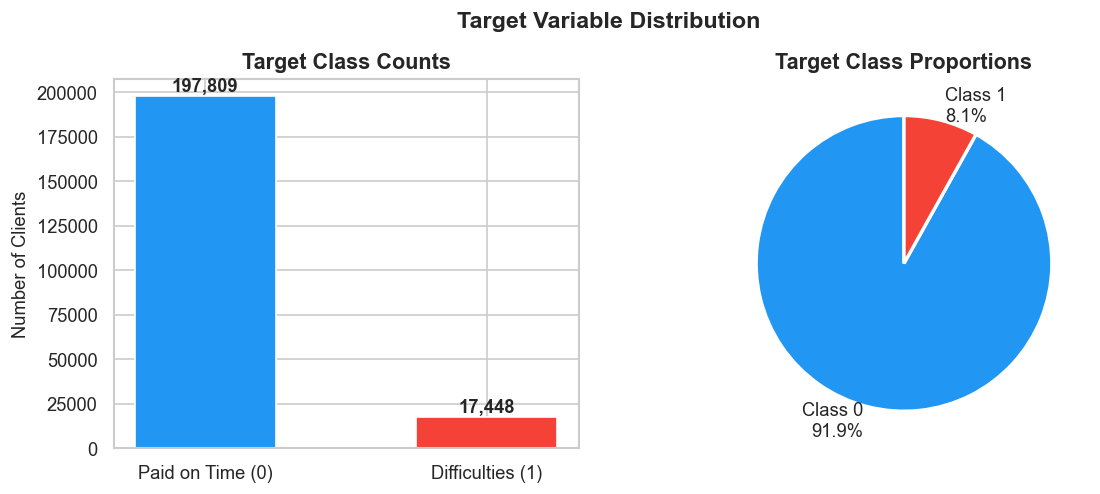

In [6]:
target_counts = db['target'].value_counts()
target_pct = db['target'].value_counts(normalize=True) * 100

print(f'Class 0 (Paid on time): {target_counts[0]:>7,}  ({target_pct[0]:.1f}%)')
print(f'Class 1 (Payment difficulty): {target_counts[1]:>7,}  ({target_pct[1]:.1f}%)')
print(f'Imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(['Paid on Time (0)', 'Difficulties (1)'], target_counts.values,
                   color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Target Class Counts', fontweight='bold')
axes[0].set_ylabel('Number of Clients')

# Pie
axes[1].pie(target_counts.values, labels=[f'Class 0\n{target_pct[0]:.1f}%', f'Class 1\n{target_pct[1]:.1f}%'],
            colors=['#2196F3', '#F44336'], startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 11})
axes[1].set_title('Target Class Proportions', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout

In [7]:
def missing_data(df: pd.DataFrame) -> pd.DataFrame:
    missing_count = df.isnull().sum()
    missing_pct   = 100 * missing_count / len(df)
    table = (
        pd.concat([missing_count, missing_pct], axis=1)
        .rename(columns={0: 'Total_Missing', 1: 'Pct_Missing'})
        .query('Pct_Missing > 0')
        .sort_values('Pct_Missing', ascending=False)
        .round(1)
    )
    print(f'Total columns          : {df.shape[1]}')
    print(f'Columns with any null  : {len(table)}')
    print(f'Columns >30% missing   : {(table["Pct_Missing"] > 30).sum()}')
    return table


mv = missing_data(db)
mv.head(20)

Total columns          : 102
Columns with any null  : 50
Columns >30% missing   : 33


,Total_Missing,Pct_Missing
nonlivingapartments_avg,149323,69.4
nonlivingapartments_mode,149323,69.4
nonlivingapartments_medi,149323,69.4
floorsmin_medi,145861,67.8
floorsmin_mode,145861,67.8
floorsmin_avg,145861,67.8
years_build_avg,142965,66.4
years_build_medi,142965,66.4
years_build_mode,142965,66.4
own_car_age,141952,65.9


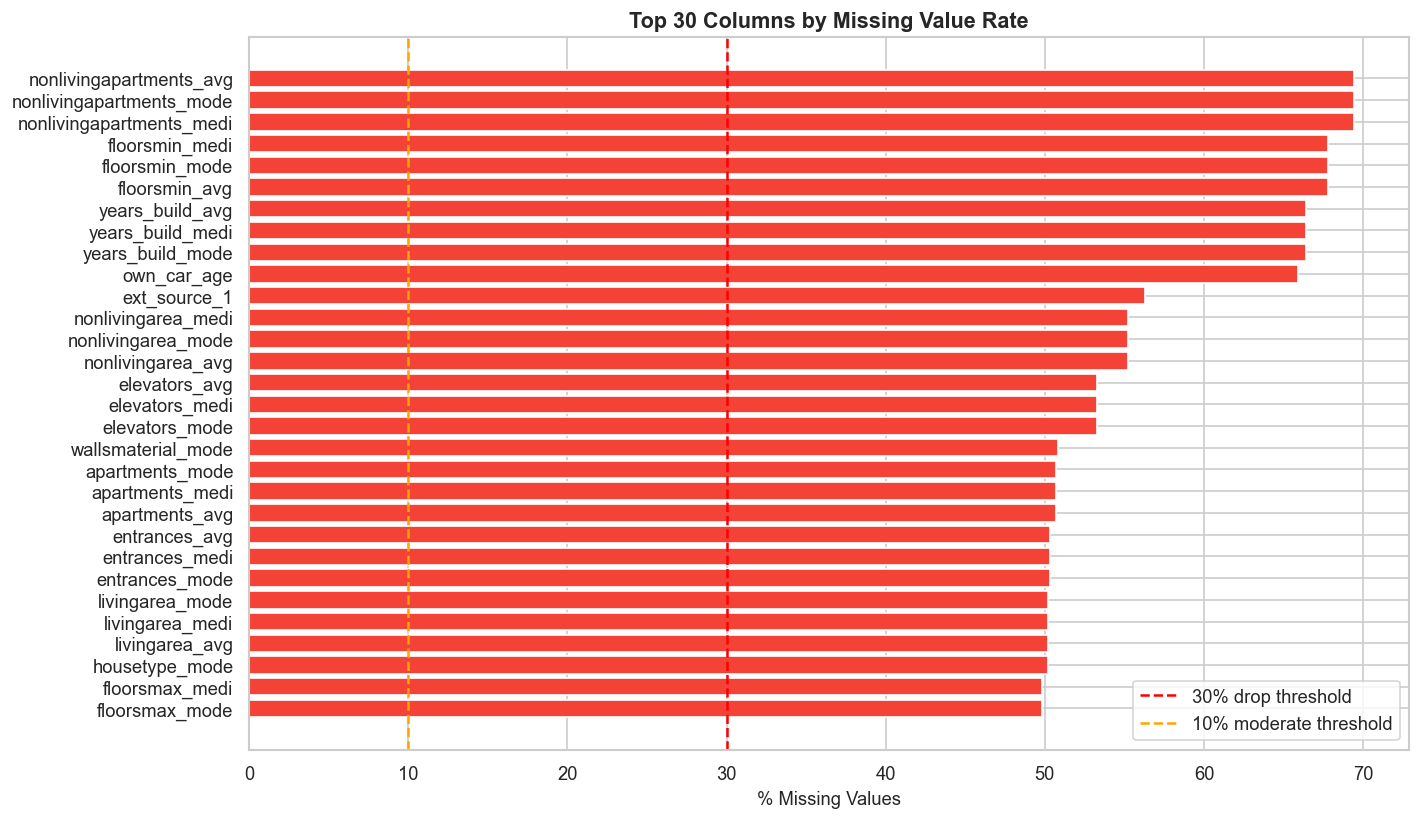

Columns that will be dropped (>30% missing): 33


In [8]:
top_missing = mv.head(30)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#F44336' if p > 30 else '#FF9800' if p > 10 else '#4CAF50'
          for p in top_missing['Pct_Missing']]
bars = ax.barh(top_missing.index[::-1], top_missing['Pct_Missing'].values[::-1],
               color=colors[::-1], edgecolor='white')
ax.axvline(30, color='red', linestyle='--', linewidth=1.5, label='30% drop threshold')
ax.axvline(10, color='orange', linestyle='--', linewidth=1.5, label='10% moderate threshold')
ax.set_xlabel('% Missing Values')
ax.set_title('Top 30 Columns by Missing Value Rate', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Columns that will be dropped (>30% missing): {(mv["Pct_Missing"] > 30).sum()}')

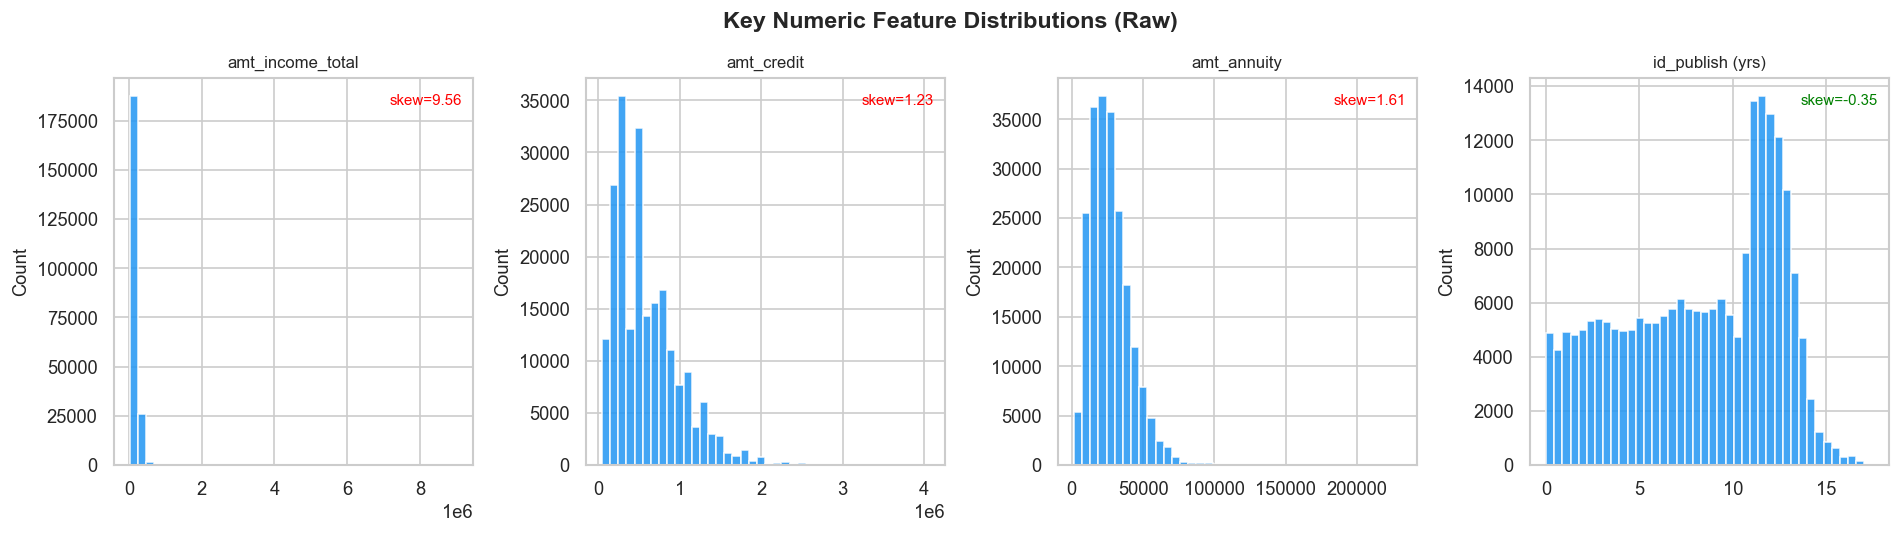

In [9]:
# Key financial/demographic features to inspect
KEY_NUMERICS = [
    'amt_income_total','amt_credit','amt_annuity','days_birth''days_employed','days_registration','days_id_publish'
]
key_num_cols = [c for c in KEY_NUMERICS if c in db.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_num_cols):
    data = abs(db[col].dropna())  
    if col.startswith('days'):
        data = data / 365  
        label = col.replace('days_', '') + ' (yrs)'
    else:
        label = col

    axes[i].hist(data, bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
    axes[i].set_title(label, fontsize=10)
    axes[i].set_ylabel('Count')
    skew_val = data.skew()
    axes[i].annotate(f'skew={skew_val:.2f}', xy=(0.97, 0.93), xycoords='axes fraction',
                     ha='right', fontsize=9,
                     color='red' if abs(skew_val) > 1 else 'green')

# Hide unused axes
for j in range(len(key_num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Key Numeric Feature Distributions (Raw)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

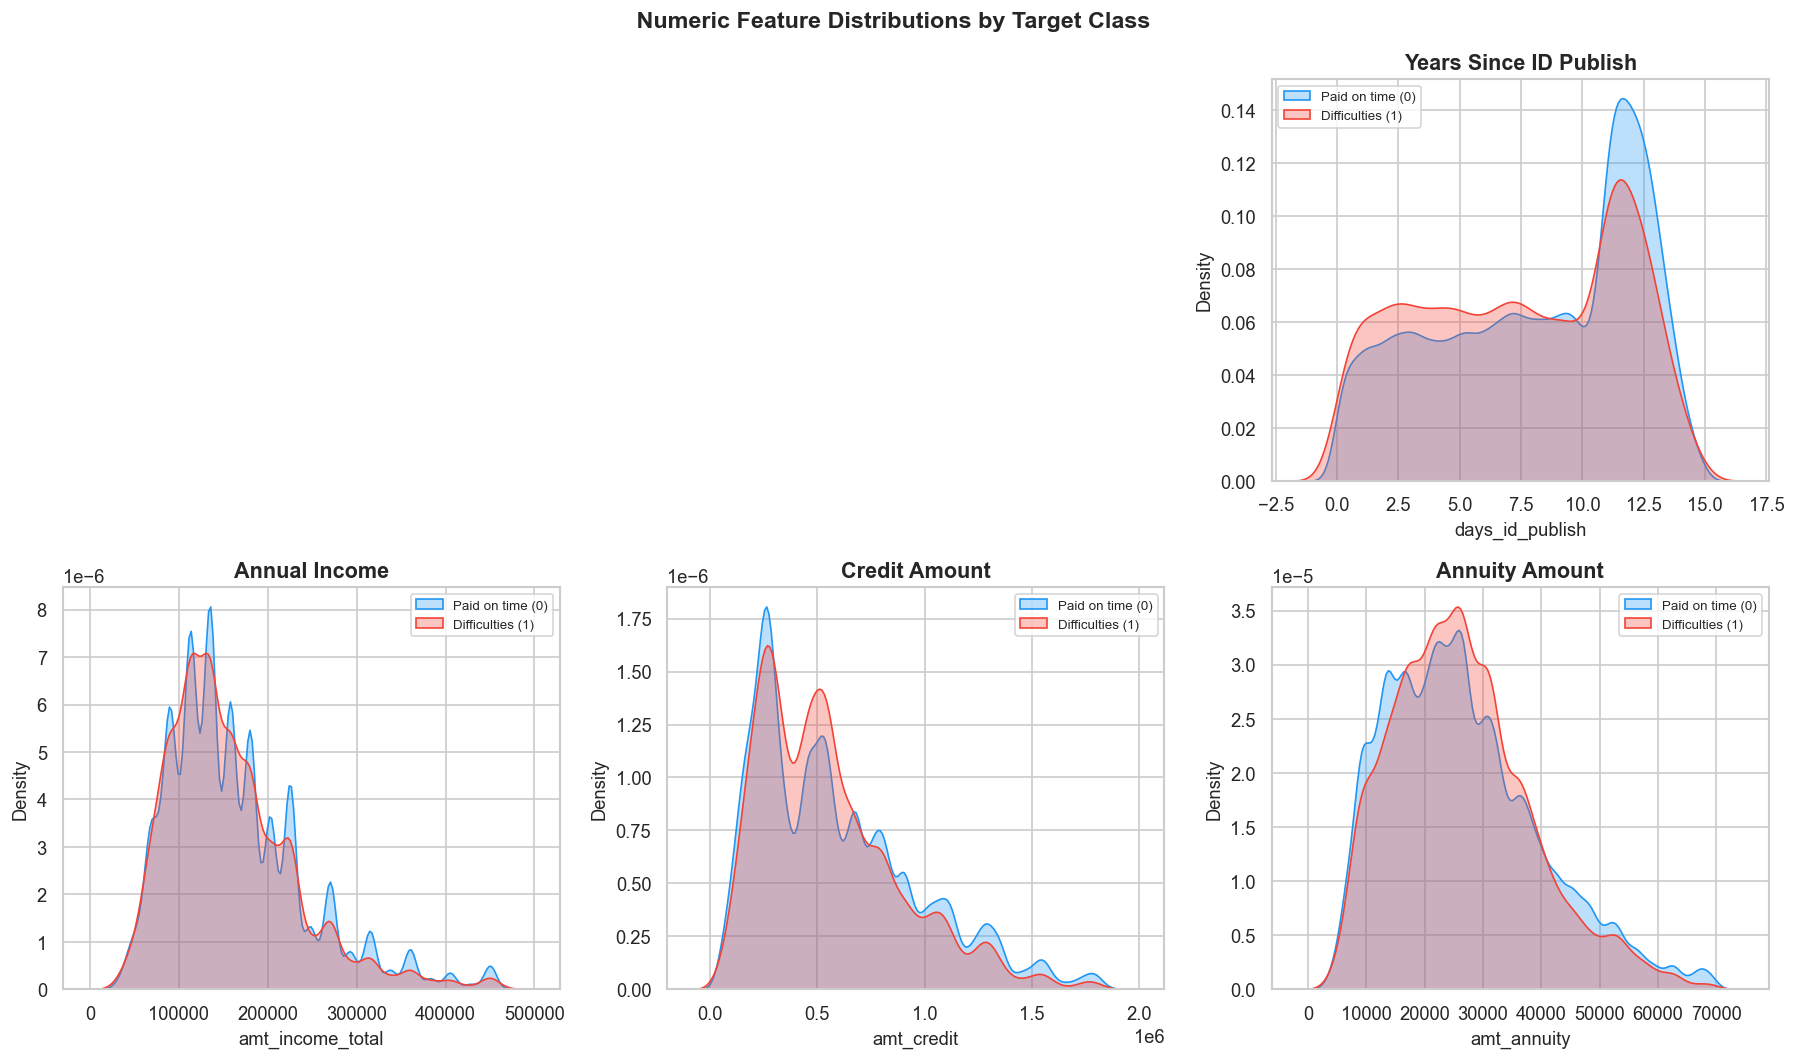

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

KDE_FEATURES = [
    ('days_birth','Age (years)',True),
    ('days_employed','Employment Duration (yrs)',True),
    ('days_id_publish','Years Since ID Publish',True),
    ('amt_income_total','Annual Income',False),
    ('amt_credit','Credit Amount',False),
    ('amt_annuity', 'Annuity Amount',False),
]

for i, (col, label, to_years) in enumerate(KDE_FEATURES):
    if col not in db.columns:
        axes[i].set_visible(False)
        continue

    data_0 = abs(db.loc[db['target'] == 0, col].dropna())
    data_1 = abs(db.loc[db['target'] == 1, col].dropna())
    if to_years:
        data_0, data_1 = data_0 / 365, data_1 / 365

    # Cap extreme outliers for visibility (99th percentile)
    cap = np.percentile(pd.concat([data_0, data_1]), 99)
    data_0 = data_0[data_0 <= cap]
    data_1 = data_1[data_1 <= cap]

    sns.kdeplot(data_0, ax=axes[i], label='Paid on time (0)', color='#2196F3', fill=True, alpha=0.3)
    sns.kdeplot(data_1, ax=axes[i], label='Difficulties (1)', color='#F44336', fill=True, alpha=0.3)
    axes[i].set_title(label, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle(' Numeric Feature Distributions by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

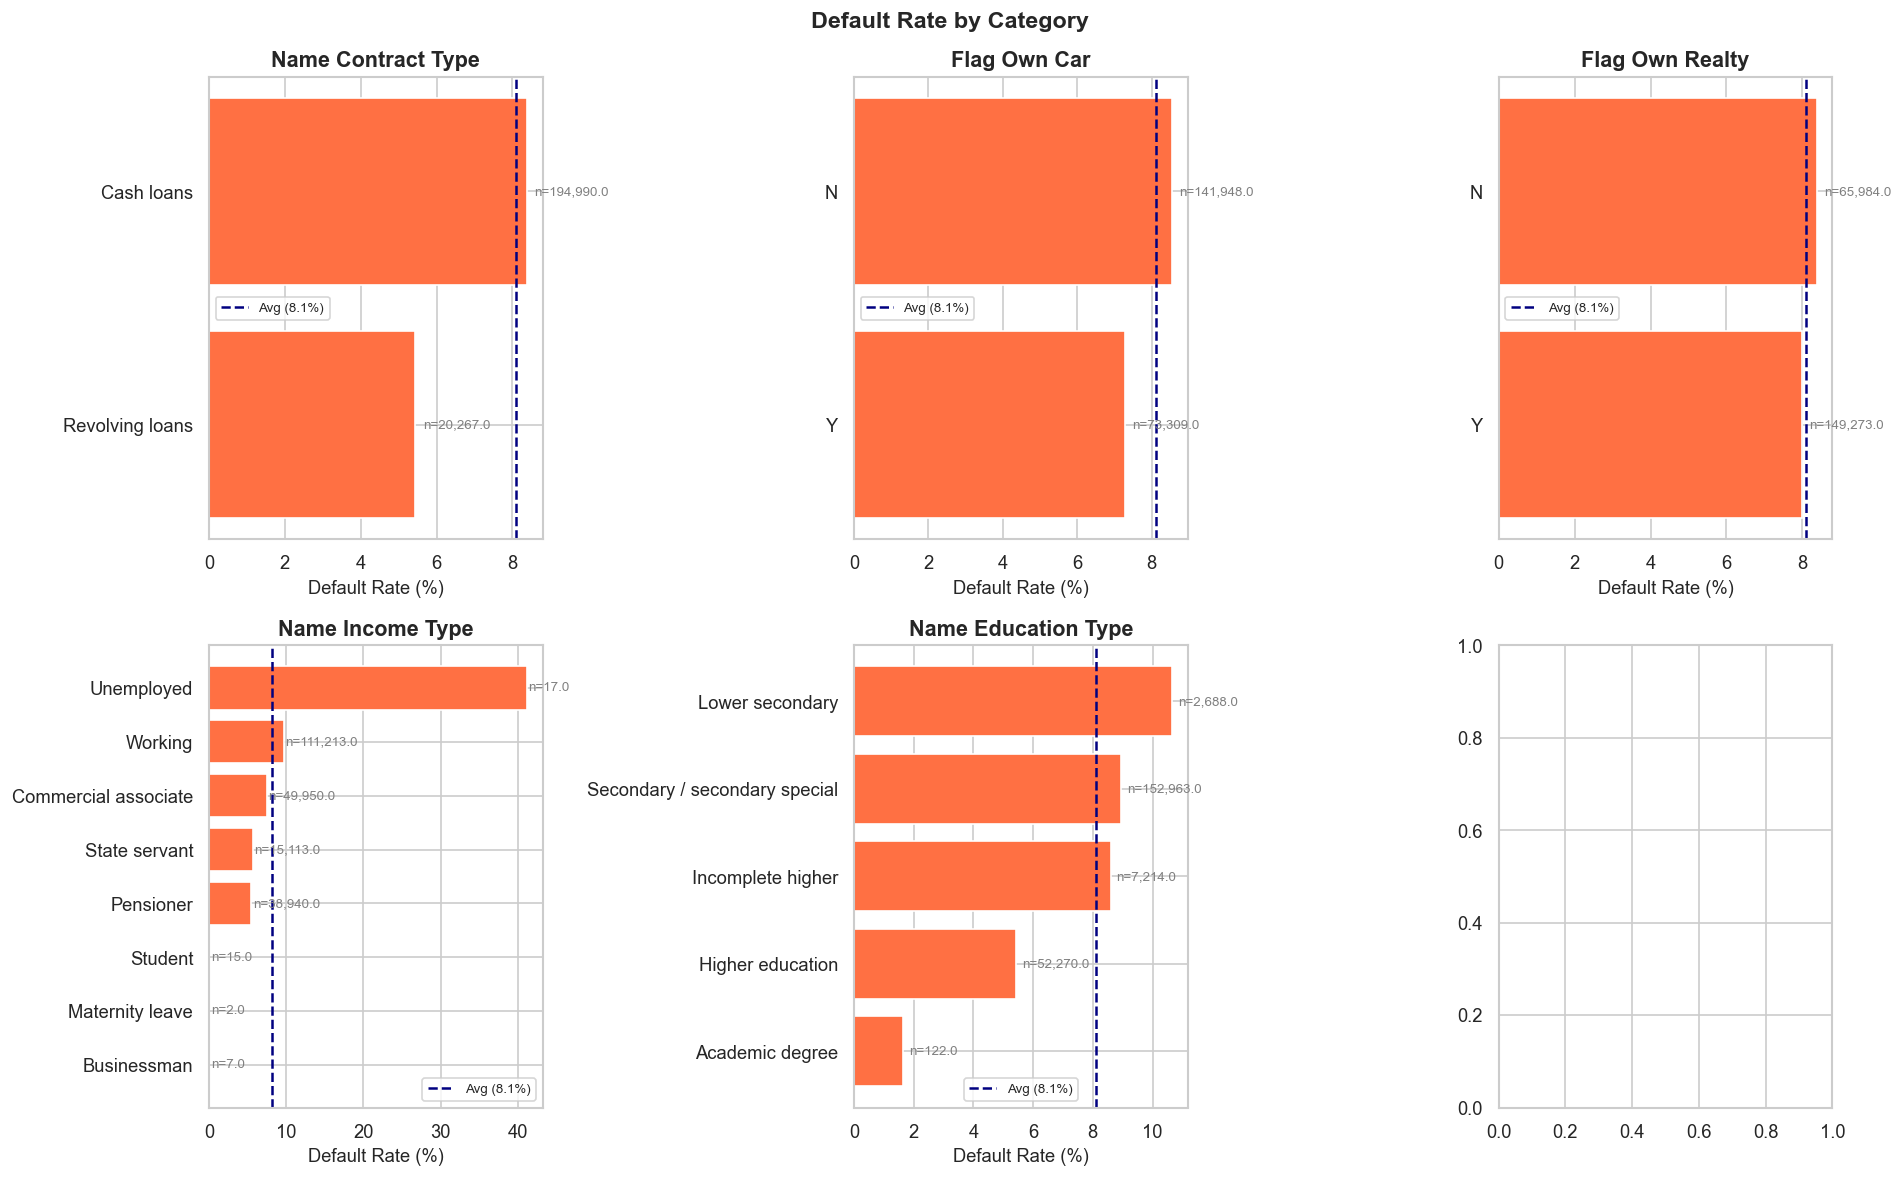

In [11]:
CAT_FEATURES = [
    'name_contract_type', 'code_gender', 'flag_own_car',
    'flag_own_realty', 'name_income_type', 'name_education_type'
]
cat_features = [c for c in CAT_FEATURES if c in db.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Default rate per category
    default_rate = (
        db.groupby(col)['target']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'default_rate', 'count': 'n'})
        .sort_values('default_rate', ascending=True)
    )

    bars = axes[i].barh(default_rate.index, default_rate['default_rate'] * 100,
                        color='#FF7043', edgecolor='white')
    for bar, (idx, row) in zip(bars, default_rate.iterrows()):
        axes[i].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                     f'n={row["n"]:,}', va='center', fontsize=8, color='gray')
    axes[i].axvline(db['target'].mean() * 100, color='navy', linestyle='--',
                    linewidth=1.5, label=f'Avg ({db["target"].mean()*100:.1f}%)')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Default Rate (%)')
    axes[i].legend(fontsize=8)

plt.suptitle('Default Rate by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

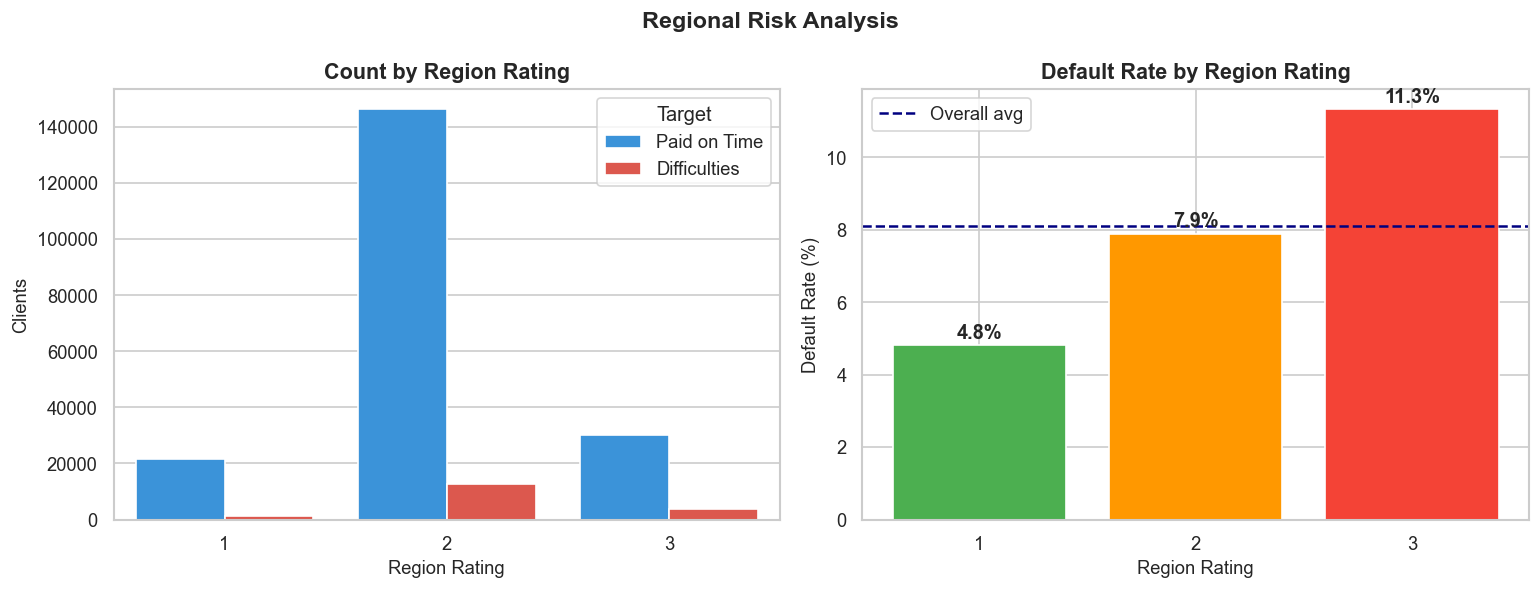

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(
    x='region_rating_client', hue='target', data=db,
    ax=axes[0], palette=['#2196F3', '#F44336']
)
axes[0].set_title('Count by Region Rating', fontweight='bold')
axes[0].set_xlabel('Region Rating')
axes[0].set_ylabel('Clients')
axes[0].legend(['Paid on Time', 'Difficulties'], title='Target')

region_rate = (
    db.groupby('region_rating_client')['target']
    .mean() * 100
).reset_index()
region_rate.columns = ['region_rating_client', 'default_rate']

axes[1].bar(region_rate['region_rating_client'].astype(str),
            region_rate['default_rate'],
            color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='white')
axes[1].axhline(db['target'].mean() * 100, color='navy', linestyle='--', label='Overall avg')
for _, row in region_rate.iterrows():
    axes[1].text(str(int(row['region_rating_client'])),
                 row['default_rate'] + 0.2,
                 f"{row['default_rate']:.1f}%", ha='center', fontweight='bold')
axes[1].set_title('Default Rate by Region Rating', fontweight='bold')
axes[1].set_xlabel('Region Rating')
axes[1].set_ylabel('Default Rate (%)')
axes[1].legend()

plt.suptitle('Regional Risk Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

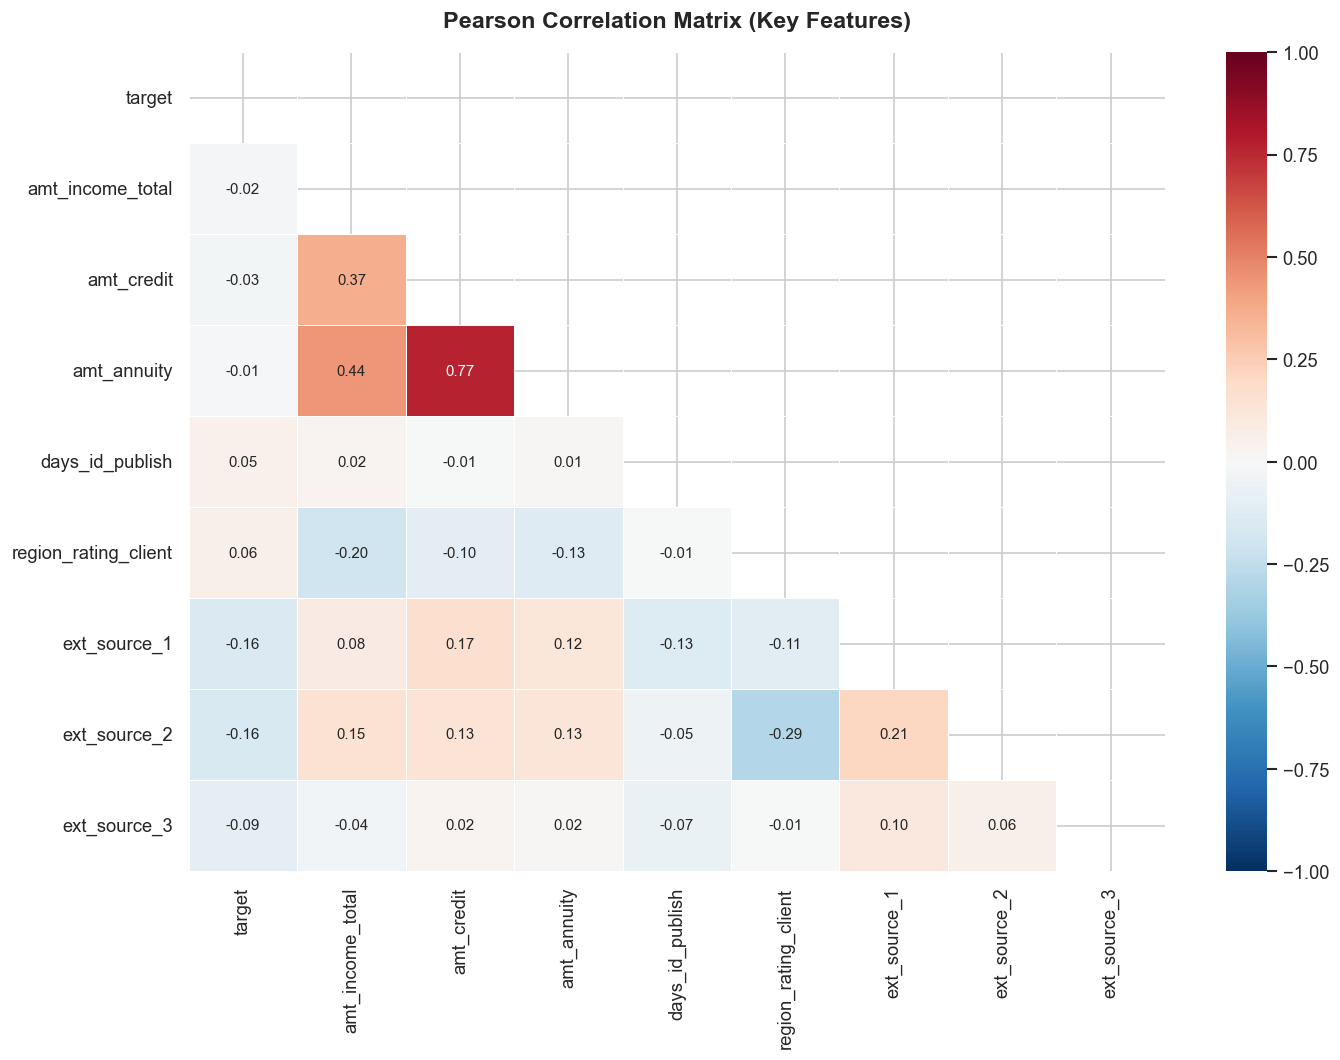


Top correlations with TARGET (absolute value):
ext_source_2            0.161
ext_source_1            0.156
ext_source_3            0.095
region_rating_client    0.061
days_id_publish         0.049
amt_credit              0.029
amt_income_total        0.021
amt_annuity             0.012


In [13]:
CORR_COLS = [
    'target', 'amt_income_total', 'amt_credit', 'amt_annuity','days_birth', 'days_employed', 'days_registration', 'days_id_publish','region_rating_client', 'ext_source_1', 'ext_source_2', 'ext_source_3'
]
corr_cols = [c for c in CORR_COLS if c in db.columns]
corr = db[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle only
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
    annot_kws={'size': 9}
)
ax.set_title('Pearson Correlation Matrix (Key Features)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\nTop correlations with TARGET (absolute value):')
print(corr['target'].drop('target').abs().sort_values(ascending=False).round(3).to_string())

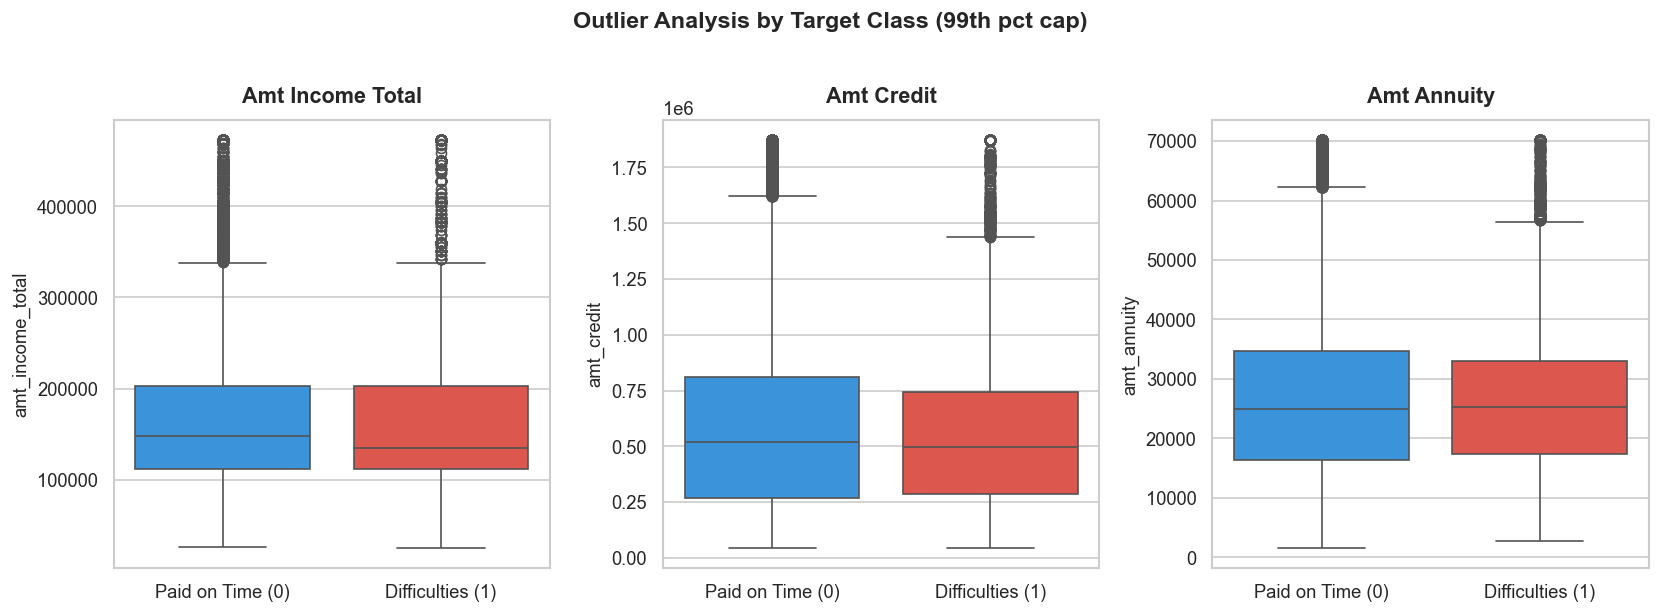

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

OUTLIER_COLS = ['amt_income_total', 'amt_credit', 'amt_annuity']
outlier_cols = [c for c in OUTLIER_COLS if c in db.columns]

if len(outlier_cols) > 0:
    fig, axes = plt.subplots(1, len(outlier_cols), figsize=(14, 5))
    
    if len(outlier_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, outlier_cols):
        plot_data = db[[col, 'target']].copy()
        plot_data['target'] = plot_data['target'].astype(str).map({
            '0': 'Paid on Time (0)',
            '1': 'Difficulties (1)'
        })
        
        upper_limit = plot_data[col].quantile(0.99)
        plot_data[col] = plot_data[col].clip(upper=upper_limit)
        sns.boxplot(
            data=plot_data, 
            x='target', 
            y=col, 
            order=['Paid on Time (0)', 'Difficulties (1)'],  # Enforces exact order
            palette={'Paid on Time (0)': '#2196F3', 'Difficulties (1)': '#F44336'}, 
            ax=ax
        )
        
        ax.set_title(col.replace('_', ' ').title(), fontweight='bold', pad=10)
        ax.set_xlabel('')

    plt.suptitle('Outlier Analysis by Target Class (99th pct cap)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("None of the specified OUTLIER_COLS were found in the dataframe.")

In [15]:
num_cols  = db.select_dtypes(include=['int64','float64']).columns
cat_cols  = db.select_dtypes(include='object').columns
drop_cols = mv[mv['Pct_Missing'] > 30].index


print('EDA SUMMARY — PREPROCESSING DECISIONS')
print(f'Dataset size: {db.shape[0]:,} rows × {db.shape[1]} columns')
print(f'Class imbalance ratio  : {(db["target"]==0).sum()/(db["target"]==1).sum():.1f}:1')
print(f'Numeric columns        : {len(num_cols)}')
print(f'Categorical columns    : {len(cat_cols)}')
print(f'Columns to drop (>30%) : {len(drop_cols)} → {list(drop_cols[:5])} ...')
print()
print('INFORMED DECISIONS:')
print('  1. Drop columns >30% missing ')
print('  2. Median imputation for numeric cols ')
print('  3. Fill categorical nulls with "No value" (')
print('  4. abs(days_*) / 365 for interpretability ')
print('  5. Use ROC-AUC as primary metric ')
print('  6. ext_source_2/3 are top predictors — ensure they are NOT dropped')
print()


EDA SUMMARY — PREPROCESSING DECISIONS
Dataset size: 215,257 rows × 102 columns
Class imbalance ratio  : 11.3:1
Numeric columns        : 88
Categorical columns    : 14
Columns to drop (>30%) : 33 → ['nonlivingapartments_avg', 'nonlivingapartments_mode', 'nonlivingapartments_medi', 'floorsmin_medi', 'floorsmin_mode'] ...

INFORMED DECISIONS:
  1. Drop columns >30% missing 
  2. Median imputation for numeric cols 
  3. Fill categorical nulls with "No value" (
  4. abs(days_*) / 365 for interpretability 
  5. Use ROC-AUC as primary metric 
  6. ext_source_2/3 are top predictors — ensure they are NOT dropped



#### **3.0 Data Preparation**

In [16]:
def missing_data(df) :
    # Total missing values
    missing_values = df.isnull().sum()

    # Persentage of missing values
    missing_values_per = 100* missing_values/ len(df)

    # Table 
    missing_values_table = pd.concat([missing_values , missing_values_per], axis= 1)

    # Rename Table 
    missing_values_table = missing_values_table.rename(columns = {0 : 'Total_Missing_value' , 1: '%_Total_missing_Value'})

    # Sorting by missing values 
    missing_values_table = missing_values_table[missing_values_table.iloc[:,1] != 0 ].sort_values('%_Total_missing_Value' , ascending=False).round(1)

    # Print 
    print ("There are " , str(df.shape[1]), "Columns")
    print (len(missing_values_table), "Colums with missing Value")
    print ((len(missing_values_table[missing_values_table.iloc[:,1] > 30 ])) , "Colums have more that 30 % missing value")
    return missing_values_table


In [17]:
missing_data(db)

There are  102 Columns
50 Colums with missing Value
33 Colums have more that 30 % missing value


,Total_Missing_value,%_Total_missing_Value
nonlivingapartments_avg,149323,69.4
nonlivingapartments_mode,149323,69.4
nonlivingapartments_medi,149323,69.4
floorsmin_medi,145861,67.8
floorsmin_mode,145861,67.8
floorsmin_avg,145861,67.8
years_build_avg,142965,66.4
years_build_medi,142965,66.4
years_build_mode,142965,66.4
own_car_age,141952,65.9


In [18]:
# Dropping Data above 30% missing value 
threshold = int(0.7 * db.shape[0] +1 )
db = db.dropna(axis=1 , thresh= threshold )

In [19]:
int(0.7 * db.shape[0] +1)

150680

In [20]:
missing_data(db)

There are  69 Columns
17 Colums with missing Value
0 Colums have more that 30 % missing value


,Total_Missing_value,%_Total_missing_Value
ext_source_3,42705,19.8
amt_req_credit_bureau_mon,29095,13.5
amt_req_credit_bureau_week,29095,13.5
amt_req_credit_bureau_qrt,29095,13.5
amt_req_credit_bureau_year,29095,13.5
amt_req_credit_bureau_day,29095,13.5
amt_req_credit_bureau_hour,29095,13.5
name_type_suite,909,0.4
def_30_cnt_social_circle,710,0.3
def_60_cnt_social_circle,710,0.3


In [21]:
db.info()
db.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215257 entries, 0 to 215256
Data columns (total 69 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           215257 non-null  int64  
 1   name_contract_type           215257 non-null  object 
 2   gender                       215257 non-null  object 
 3   flag_own_car                 215257 non-null  object 
 4   flag_own_realty              215257 non-null  object 
 5   cnt_children                 215257 non-null  int64  
 6   amt_income_total             215257 non-null  float64
 7   amt_credit                   215257 non-null  float64
 8   amt_annuity                  215249 non-null  float64
 9   amt_goods_price              215054 non-null  float64
 10  name_type_suite              214348 non-null  object 
 11  name_income_type             215257 non-null  object 
 12  name_education_type          215257 non-null  object 
 13 

(215257, 69)

In [22]:
# Numaric Data
db_num = db.select_dtypes(include= {'int64' , 'float64'}) # type: ignore
db_num.head()

,id,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,days_age,days_employment,days_id_publish,flag_mobil,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,cnt_fam_members,region_rating_client,region_rating_client_w_city,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,ext_source_2,ext_source_3,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year,ext_source_4,target
0,160132,0,427500.0,1288350.0,37800.0,1125000.0,-22008,365243,-4584,1,0,1,0,0,1.0,2,2,15,0,0,0,0,0,0,0.334914,0.365904,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,5.0,0.242982,0
1,233132,0,180000.0,848745.0,40963.5,675000.0,-8506,-313,-1172,1,0,1,0,0,1.0,1,1,12,0,0,0,0,0,0,0.510027,NaN,2.0,0.0,2.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.115508,0
2,307771,1,112500.0,385164.0,19795.5,292500.0,-11579,-2651,-3736,1,0,1,0,0,3.0,2,2,13,0,0,0,0,1,1,0.555162,0.039569,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.393106,0
3,376452,0,540000.0,1433520.0,60867.0,1237500.0,-21179,365243,-4628,1,0,1,0,0,2.0,1,1,16,0,0,0,0,0,0,0.730635,0.152156,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.455985,0
4,405403,0,76500.0,900000.0,26316.0,900000.0,-21210,-13767,-4427,1,1,1,0,0,2.0,3,3,9,0,0,0,0,0,0,0.634374,0.368668,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,3.0,0.0,2.0,0.141508,0


In [23]:
db_num.describe()

,id,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,days_age,days_employment,days_id_publish,flag_mobil,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,cnt_fam_members,region_rating_client,region_rating_client_w_city,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,ext_source_2,ext_source_3,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year,ext_source_4,target
count,215257.000000,215257.000000,2.152570e+05,2.152570e+05,215249.000000,2.150540e+05,215257.000000,215257.000000,215257.000000,215257.0,215257.000000,215257.000000,215257.000000,215257.000000,215255.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,2.147930e+05,1.725520e+05,214547.000000,214547.000000,214547.000000,214547.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,215257.000000,186162.000000,186162.000000,186162.000000,186162.000000,186162.000000,186162.00000,2.147930e+05,215257.000000
mean,277916.285552,0.416567,1.683448e+05,5.996394e+05,27128.366938,5.388528e+05,-16040.968814,64138.989292,-2995.073206,1.0,0.199023,0.998170,0.281482,0.056653,2.150882,2.053006,2.031906,12.061434,0.015275,0.050772,0.040607,0.078636,0.229572,0.178689,5.145661e-01,2.549942e-01,1.425781,0.143787,1.408820,0.100477,0.000056,0.710537,0.000098,0.015182,0.088555,0.000172,0.081266,0.003907,0.000023,0.004014,0.000005,0.003512,0.002936,0.001166,0.009946,0.000269,0.008130,0.000641,0.000506,0.000330,0.006494,0.006935,0.034486,0.268175,0.265264,1.90107,2.571639e-01,0.081057
std,102805.880546,0.721898,1.023409e+05,4.030145e+05,14521.116795,3.699160e+05,4367.736464,141546.368713,1509.053098,0.0,0.399266,0.042744,0.449723,0.231179,0.910791,0.509650,0.503356,3.263930,0.122644,0.219532,0.197379,0.269171,0.420559,0.383092,1.909938e-01,1.854428e-01,2.439367,0.449906,2.418131,0.364822,0.007466,0.453514,0.009877,0.122276,0.284100,0.013109,0.273243,0.062384,0.004820,0.063227,0.002155,0.059159,0.054106,0.034128,0.099234,0.016413,0.089798,0.025312,0.022497,0.018158,0.084051,0.108859,0.203859,0.922865,0.860637,1.86733,1.850209e-01,0.272923
min,100002.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,-25201.000000,-17912.000000,-6383.000000,1.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.173617e-08,6.835609e-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,2.436734e-08,0.000000
25%,188825.000000,0.000000,1.125000e+05,2.700000e+05,16551.000000,2.385000e+05,-19697.000000,-2758.000000,-4298.000000,1.0,0.000000,1.000000,0.000000,0.000000,2.000000,2.000000,2.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.926034e-01,9.923395e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,

In [24]:
# Filling Nul Values with midian
db_num = db_num.apply(pd.to_numeric , errors = 'coerce')
db_num = db_num.fillna(db_num.median())
missing_data(db_num)

There are  58 Columns
0 Colums with missing Value
0 Colums have more that 30 % missing value


,Total_Missing_value,%_Total_missing_Value


In [25]:
# Objective Data
db_object = db.select_dtypes(include= {'object'})  # type: ignore
print("Total Null Values of Objective db :" , db_object.isnull().sum().sum())
db_object.head()


Total Null Values of Objective db : 909


,name_contract_type,gender,flag_own_car,flag_own_realty,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,weekday_appr_process_start,organization_type
0,Cash loans,F,N,Y,Unaccompanied,Pensioner,Secondary / secondary special,Widow,House / apartment,MONDAY,XNA
1,Cash loans,M,Y,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,FRIDAY,Business Entity Type 3
2,Cash loans,M,Y,Y,"Spouse, partner",Working,Secondary / secondary special,Married,Rented apartment,TUESDAY,Transport: type 3
3,Cash loans,F,N,Y,Unaccompanied,Pensioner,Secondary / secondary special,Married,House / apartment,FRIDAY,XNA
4,Cash loans,M,Y,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,THURSDAY,Medicine


In [26]:
db.select_dtypes(include= 'object').nunique()

db_object = db_object.fillna('No value')
print("Total Null Values of Objective db :" , db_object.isnull().sum().sum())

Total Null Values of Objective db : 0


In [27]:
# Encoding Data 
db_object = db_object.apply(preprocessing.LabelEncoder().fit_transform)
db_object.head()

,name_contract_type,gender,flag_own_car,flag_own_realty,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,weekday_appr_process_start,organization_type
0,0,0,0,1,7,3,4,5,1,1,57
1,0,1,1,1,7,1,4,3,1,0,5
2,0,1,1,1,6,7,4,1,4,5,54
3,0,0,0,1,7,3,4,1,1,0,57
4,0,1,1,1,7,7,4,1,1,4,30


In [28]:
# Meargeing Data
train = pd.concat((db_num,db_object ),  axis= 1 ,join ='outer')
print("The shape to train data :", train.shape)
train.head()

The shape to train data : (215257, 69)


,id,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,days_age,days_employment,days_id_publish,flag_mobil,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,cnt_fam_members,region_rating_client,region_rating_client_w_city,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,ext_source_2,ext_source_3,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year,ext_source_4,target,name_contract_type,gender,flag_own_car,flag_own_realty,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,weekday_appr_process_start,organization_type
0,160132,0,427500.0,1288350.0,37800.0,1125000.0,-22008,365243,-4584,1,0,1,0,0,1.0,2,2,15,0,0,0,0,0,0,0.334914,0.365904,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,5.0,0.242982,0,0,0,0,1,7,3,4,5,1,1,57
1,233132,0,180000.0,848745.0,40963.5,675000.0,-8506,-313,-1172,1,0,1,0,0,1.0,1,1,12,0,0,0,0,0,0,0.510027,0.220164,2.0,0.0,2.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.115508,0,0,1,1,1,7,1,4,3,1,0,5
2,307771,1,112500.0,385164.0,19795.5,292500.0,-11579,-2651,-3736,1,0,1,0,0,3.0,2,2,13,0,0,0,0,1,1,0.555162,0.039569,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.393106,0,0,1,1,1,6,7,4,1,4,5,54
3,376452,0,540000.0,1433520.0,60867.0,1237500.0,-21179,365243,-4628,1,0,1,0,0,2.0,1,1,16,0,0,0,0,0,0,0.730635,0.152156,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.455985,0,0,0,0,1,7,3,4,1,1,0,57
4,405403,0,76500.0,900000.0,26316.0,900000.0,-21210,-13767,-4427,1,1,1,0,0,2.0,3,3,9,0,0,0,0,0,0,0.634374,0.368668,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,3.0,0.0,2.0,0.141508,0,0,1,1,1,7,7,4,1,1,4,30


### Validazione 

In [29]:
# importing validazione data 
validazione = pd.read_csv("validazione.csv")
validazione.head()

,ID,NAME_CONTRACT_TYPE,GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_AGE,DAYS_EMPLOYMENT,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,YEARS_BUILD_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,YEARS_BUILD_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,YEARS_BUILD_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_4
0,280205,Cash loans,M,Y,Y,0,112500.0,180000.0,12928.5,180000.0,Unaccompanied,Commercial associate,Higher education,Married,House / apartment,-17571,-290,-1082,25.0,1,1,0,1,1,0,Sales staff,2.0,2,2,SATURDAY,11,0,0,0,0,0,0,Business Entity Type 3,0.537010,0.727768,NaN,0.0701,NaN,0.0,0.1379,0.1667,NaN,0.0463,NaN,0.2060,0.0714,NaN,0.0000,0.1379,0.1667,NaN,0.0482,NaN,0.2181,0.0708,NaN,0.0,0.1379,0.1667,NaN,0.0471,NaN,0.2103,block of flats,0.0812,"Stone, brick",3.0,0.0,3.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.336738
1,178265,Cash loans,M,Y,N,2,157500.0,675000.0,34465.5,675000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,-15743,-1687,-4781,21.0,1,1,1,1,1,0,Security staff,4.0,2,2,TUESDAY,12,0,1,1,1,1,1,Business Entity Type 3,NaN,0.331222,0.340828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,0.0,5.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0,0.257440
2,119641,Cash loans,F,N,Y,0,112500.0,622188.0,26284.5,472500.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,-13916,-7307,-4609,NaN,1,1,0,1,1,0,Laborers,2.0,2,2,FRIDAY,13,0,0,0,0,0,0,Industry: type 3,0.635203,0.529903,0.102798,NaN,NaN,NaN,0.0690,0.0417,NaN,0.0125,NaN,NaN,NaN,NaN,NaN,0.0690,0.0417,NaN,0.0130,NaN,NaN,NaN,NaN,NaN,0.0690,0.0417,NaN,0.0127,NaN,NaN,NaN,0.0106,"Stone, brick",2.0,0.0,2.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,2.0,0.144186
3,294616,Cash loans,M,Y,N,0,202500.0,545040.0,25537.5,450000.0,Family,State servant,Secondary / secondary special,Civil marriage,House / apartment,-8661,-623,-1344,6.0,1,1,1,1,0,0,Core staff,2.0,1,1,THURSDAY,14,0,1,1,0,1,1,Police,0.290311,0.527783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0,0.519098
4,145313,Cash loans,F,N,Y,0,180000.0,539100.0,26064.0,450000.0,Unaccompanied,Pensioner,Secondary / secondary special,Married,House / apartment,-20798,365243,-4194,NaN,1,0,0,1,1,0,NaN,2.0,2,2,THURSD

In [30]:
validazione.isnull().sum()
validazione.shape

(92254, 102)

In [31]:
# Finding common columns
validazione = validazione.rename( columns= str.lower )

common_colms = validazione.columns.intersection(train.columns)
print(common_colms.value_counts().sum())

68


In [32]:
print (validazione[common_colms].shape)
validazione = validazione[common_colms]

validazione_num = validazione.select_dtypes(include= {'int64','float64'}) # type: ignore
validazione.head()
missing_data(validazione)

(92254, 68)
There are  68 Columns
16 Colums with missing Value
0 Colums have more that 30 % missing value


,Total_Missing_value,%_Total_missing_Value
ext_source_3,18260,19.8
amt_req_credit_bureau_week,12424,13.5
amt_req_credit_bureau_qrt,12424,13.5
amt_req_credit_bureau_year,12424,13.5
amt_req_credit_bureau_mon,12424,13.5
amt_req_credit_bureau_hour,12424,13.5
amt_req_credit_bureau_day,12424,13.5
name_type_suite,383,0.4
def_30_cnt_social_circle,311,0.3
obs_30_cnt_social_circle,311,0.3


In [33]:
validazione_num = validazione_num.apply(pd.to_numeric , errors = 'coerce')
validazione_num = db_num.fillna(validazione_num.median())
missing_data(validazione_num)

There are  58 Columns
0 Colums with missing Value
0 Colums have more that 30 % missing value


,Total_Missing_value,%_Total_missing_Value


In [34]:
validazione_object = validazione.select_dtypes(include= 'object')

validazione_object = validazione_object.fillna('No value')
print("Total Null Values of Objective db :" , validazione_object.isnull().sum().sum())
missing_data(validazione_object)

Total Null Values of Objective db : 0
There are  11 Columns
0 Colums with missing Value
0 Colums have more that 30 % missing value


,Total_Missing_value,%_Total_missing_Value


In [35]:
# Encoding
validazione_object = validazione_object.apply(preprocessing.LabelEncoder().fit_transform) # type: ignore
validazione_object.head()

,name_contract_type,gender,flag_own_car,flag_own_realty,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,weekday_appr_process_start,organization_type
0,0,1,1,1,7,1,1,1,1,2,5
1,0,1,1,0,7,1,4,1,1,5,5
2,0,0,0,1,7,7,4,1,1,0,20
3,0,1,1,0,1,4,4,0,1,4,34
4,0,0,0,1,7,3,4,1,1,4,57


In [36]:
validazione = pd.concat((validazione_num,validazione_object ),  axis= 1 ,join ='outer')
print("The shape to train data :", validazione.shape)
validazione.head()

The shape to train data : (215257, 69)


,id,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,days_age,days_employment,days_id_publish,flag_mobil,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,cnt_fam_members,region_rating_client,region_rating_client_w_city,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,ext_source_2,ext_source_3,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year,ext_source_4,target,name_contract_type,gender,flag_own_car,flag_own_realty,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,weekday_appr_process_start,organization_type
0,160132,0,427500.0,1288350.0,37800.0,1125000.0,-22008,365243,-4584,1,0,1,0,0,1.0,2,2,15,0,0,0,0,0,0,0.334914,0.365904,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,5.0,0.242982,0,0.0,1.0,1.0,1.0,7.0,1.0,1.0,1.0,1.0,2.0,5.0
1,233132,0,180000.0,848745.0,40963.5,675000.0,-8506,-313,-1172,1,0,1,0,0,1.0,1,1,12,0,0,0,0,0,0,0.510027,0.220164,2.0,0.0,2.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.115508,0,0.0,1.0,1.0,0.0,7.0,1.0,4.0,1.0,1.0,5.0,5.0
2,307771,1,112500.0,385164.0,19795.5,292500.0,-11579,-2651,-3736,1,0,1,0,0,3.0,2,2,13,0,0,0,0,1,1,0.555162,0.039569,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.393106,0,0.0,0.0,0.0,1.0,7.0,7.0,4.0,1.0,1.0,0.0,20.0
3,376452,0,540000.0,1433520.0,60867.0,1237500.0,-21179,365243,-4628,1,0,1,0,0,2.0,1,1,16,0,0,0,0,0,0,0.730635,0.152156,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.455985,0,0.0,1.0,1.0,0.0,1.0,4.0,4.0,0.0,1.0,4.0,34.0
4,405403,0,76500.0,900000.0,26316.0,900000.0,-21210,-13767,-4427,1,1,1,0,0,2.0,3,3,9,0,0,0,0,0,0,0.634374,0.368668,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,3.0,0.0,2.0,0.141508,0,0.0,0.0,0.0,1.0,7.0,3.0,4.0,1.0,1.0,4.0,57.0


In [37]:
# Some Important Formulas 

train['credit_income_percent'] = train['amt_credit'] / train['amt_income_total']
train['annuity_income_percent'] = train['amt_annuity'] / train['amt_income_total']
train['credit_term'] = train['amt_annuity'] / train['amt_credit']
train['days_employed_percent'] = train['days_employment'] / train['days_age']

validazione['credit_income_percent'] = validazione['amt_credit'] / validazione['amt_income_total']
validazione['annuity_income_percent'] = validazione['amt_annuity'] / validazione['amt_income_total']
validazione['credit_term'] = validazione['amt_annuity'] / validazione['amt_credit']
validazione['days_employed_percent'] = validazione['days_employment'] / validazione['days_age']

In [38]:
train.head()

,id,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,days_age,days_employment,days_id_publish,flag_mobil,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,cnt_fam_members,region_rating_client,region_rating_client_w_city,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,ext_source_2,ext_source_3,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year,ext_source_4,target,name_contract_type,gender,flag_own_car,flag_own_realty,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,weekday_appr_process_start,organization_type,credit_income_percent,annuity_income_percent,credit_term,days_employed_percent
0,160132,0,427500.0,1288350.0,37800.0,1125000.0,-22008,365243,-4584,1,0,1,0,0,1.0,2,2,15,0,0,0,0,0,0,0.334914,0.365904,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,5.0,0.242982,0,0,0,0,1,7,3,4,5,1,1,57,3.013684,0.088421,0.029340,-16.595920
1,233132,0,180000.0,848745.0,40963.5,675000.0,-8506,-313,-1172,1,0,1,0,0,1.0,1,1,12,0,0,0,0,0,0,0.510027,0.220164,2.0,0.0,2.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.115508,0,0,1,1,1,7,1,4,3,1,0,5,4.715250,0.227575,0.048264,0.036798
2,307771,1,112500.0,385164.0,19795.5,292500.0,-11579,-2651,-3736,1,0,1,0,0,3.0,2,2,13,0,0,0,0,1,1,0.555162,0.039569,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.393106,0,0,1,1,1,6,7,4,1,4,5,54,3.423680,0.175960,0.051395,0.228949
3,376452,0,540000.0,1433520.0,60867.0,1237500.0,-21179,365243,-4628,1,0,1,0,0,2.0,1,1,16,0,0,0,0,0,0,0.730635,0.152156,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.455985,0,0,0,0,1,7,3,4,1,1,0,57,2.654667,0.112717,0.042460,-17.245526
4,405403,0,76500.0,900000.0,26316.0,900000.0,-21210,-13767,-4427,1,1,1,0,0,2.0,3,3,9,0,0,0,0,0,0,0.634374,0.368668,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,3.0,0.0,2.0,0.141508,0,0,1,1,1,7,7,4,1,1,4,30,11.764706,0.344000,0.029240,0.649081


In [39]:
validazione.head()

,id,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,days_age,days_employment,days_id_publish,flag_mobil,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,cnt_fam_members,region_rating_client,region_rating_client_w_city,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,ext_source_2,ext_source_3,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year,ext_source_4,target,name_contract_type,gender,flag_own_car,flag_own_realty,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,weekday_appr_process_start,organization_type,credit_income_percent,annuity_income_percent,credit_term,days_employed_percent
0,160132,0,427500.0,1288350.0,37800.0,1125000.0,-22008,365243,-4584,1,0,1,0,0,1.0,2,2,15,0,0,0,0,0,0,0.334914,0.365904,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,5.0,0.242982,0,0.0,1.0,1.0,1.0,7.0,1.0,1.0,1.0,1.0,2.0,5.0,3.013684,0.088421,0.029340,-16.595920
1,233132,0,180000.0,848745.0,40963.5,675000.0,-8506,-313,-1172,1,0,1,0,0,1.0,1,1,12,0,0,0,0,0,0,0.510027,0.220164,2.0,0.0,2.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.115508,0,0.0,1.0,1.0,0.0,7.0,1.0,4.0,1.0,1.0,5.0,5.0,4.715250,0.227575,0.048264,0.036798
2,307771,1,112500.0,385164.0,19795.5,292500.0,-11579,-2651,-3736,1,0,1,0,0,3.0,2,2,13,0,0,0,0,1,1,0.555162,0.039569,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.393106,0,0.0,0.0,0.0,1.0,7.0,7.0,4.0,1.0,1.0,0.0,20.0,3.423680,0.175960,0.051395,0.228949
3,376452,0,540000.0,1433520.0,60867.0,1237500.0,-21179,365243,-4628,1,0,1,0,0,2.0,1,1,16,0,0,0,0,0,0,0.730635,0.152156,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.455985,0,0.0,1.0,1.0,0.0,1.0,4.0,4.0,0.0,1.0,4.0,34.0,2.654667,0.112717,0.042460,-17.245526
4,405403,0,76500.0,900000.0,26316.0,900000.0,-21210,-13767,-4427,1,1,1,0,0,2.0,3,3,9,0,0,0,0,0,0,0.634374,0.368668,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,3.0,0.0,2.0,0.141508,0,0.0,0.0,0.0,1.0,7.0,3.0,4.0,1.0,1.0,4.0,57.0,11.764706,0.344000,0.029240,0.649081


#### 4.0 Modelling

##### Identify the set of variables to use for predictions

In [40]:
train = train.drop(train.loc[:, 'flag_document_2':'flag_document_21' ].columns, axis = 1)
train = train.drop('id', axis = 1)

validazione = validazione.drop(validazione.loc[:, 'flag_document_2':'flag_document_21'].columns, axis = 1)
validazione = validazione.drop('id' , axis = 1)

In [41]:
train['target'].value_counts()

target
0    197809
1     17448
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

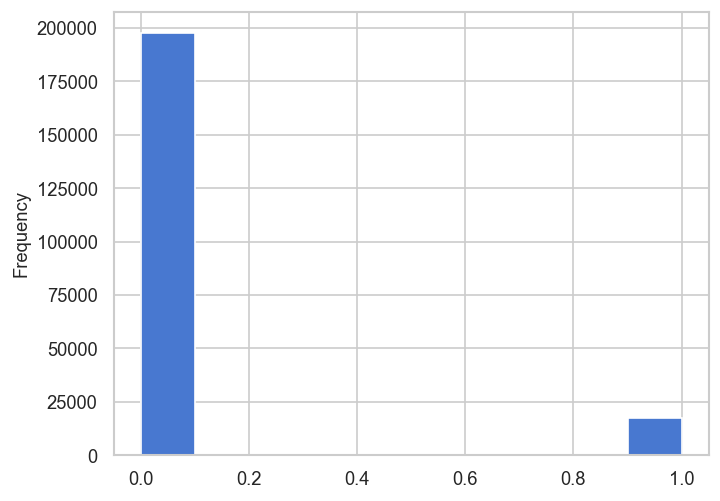

In [42]:
train['target'].astype('int').plot.hist()

In [43]:
#It is unbalaced classification because there are much more loans that were paid on time than not paid ones.

In [44]:

print( "Paid on time Percentage" , round(train['target'].value_counts(normalize = True)[0] * 100 ,2) , "%")
print ( "Not Paid on Time Percentage" , 100 - round(train['target'].value_counts(normalize = True)[0] * 100 ,2), "%")

Paid on time Percentage 91.89 %
Not Paid on Time Percentage 8.11 %


In [45]:
# Splitting into develop and test sets
X = train.drop('target', axis=1)
y = train['target']

X_develop, X_test, y_develop, y_test = train_test_split(X, y, test_size=0.6, random_state=42)

In [46]:
print( "Paid on time y_develop Percentage" , round(y_develop.value_counts(normalize = True)[0] * 100 ,2) , "%")
print ( "Not Paid on Time y_develop Percentage" , (round(y_develop.value_counts(normalize = True)[1] * 100 , 2)), "% \n")

print( "Paid on time y_test Percentage" , round(y_test.value_counts(normalize = True)[0] * 100 ,2) , "%")
print ( "Not Paid on Time y_test Percentage" , 100 - (round(y_test.value_counts(normalize = True)[0] * 100 ,2)), "%")

Paid on time y_develop Percentage 91.9 %
Not Paid on Time y_develop Percentage 8.1 % 

Paid on time y_test Percentage 91.89 %
Not Paid on Time y_test Percentage 8.11 %


In [47]:
correlation = train.corr(numeric_only=True)

print(correlation["target"].sort_values(ascending=False))


target                         1.000000
days_age                       0.077656
region_rating_client_w_city    0.063146
region_rating_client           0.061325
name_education_type            0.053632
gender                         0.053457
days_id_publish                0.048777
reg_city_not_work_city         0.048667
name_income_type               0.047641
reg_city_not_live_city         0.045275
days_employed_percent          0.041470
name_housing_type              0.034521
def_30_cnt_social_circle       0.032793
def_60_cnt_social_circle       0.030966
live_city_not_work_city        0.030225
flag_work_phone                0.029905
cnt_children                   0.017961
annuity_income_percent         0.015765
amt_req_credit_bureau_year     0.013957
credit_term                    0.011830
obs_30_cnt_social_circle       0.010814
obs_60_cnt_social_circle       0.010676
name_type_suite                0.009011
reg_region_not_work_region     0.008617
reg_region_not_live_region     0.007978


In [48]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=10
)

X_new = selector.fit_transform(X, y)

selected_features = X.columns[
    selector.get_support()
]

print(selected_features)

Index(['days_age', 'days_id_publish', 'region_rating_client', 'region_rating_client_w_city', 'reg_city_not_work_city', 'ext_source_2', 'ext_source_3', 'ext_source_4', 'gender', 'name_education_type'], dtype='object')


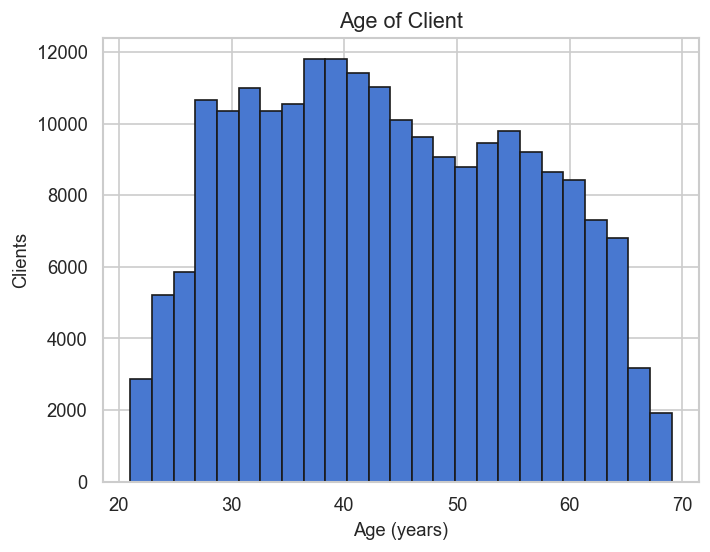

In [49]:
plt.hist(abs(train['days_age']) / 365, edgecolor = 'k', bins = 25)
plt.title('Age of Client'); plt.xlabel('Age (years)'); plt.ylabel('Clients');

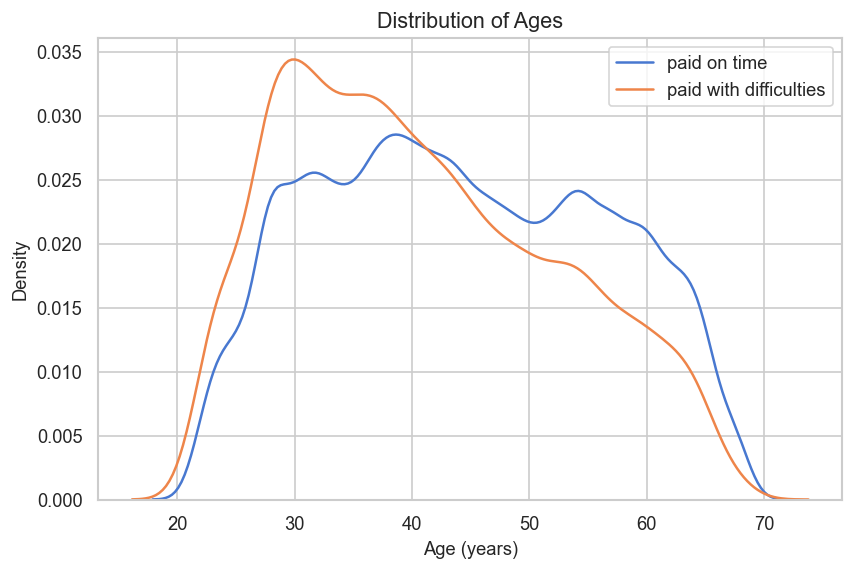

In [50]:
#Let us plot the distribution 
plt.figure(figsize = (8, 5))

# KDE plot of loans with customers that paid on time
sns.kdeplot(abs(train.loc[train['target'] == 0, 'days_age'] / 365), label = 'paid on time')

# KDE plot of loans of customers that had difficulties with paying on time
sns.kdeplot(abs(train.loc[train['target'] == 1, 'days_age'] / 365), label = 'paid with difficulties')

# Labeling of plot
plt.xlabel('Age (years)'); plt.ylabel('Density'); plt.title('Distribution of Ages');
plt.legend()

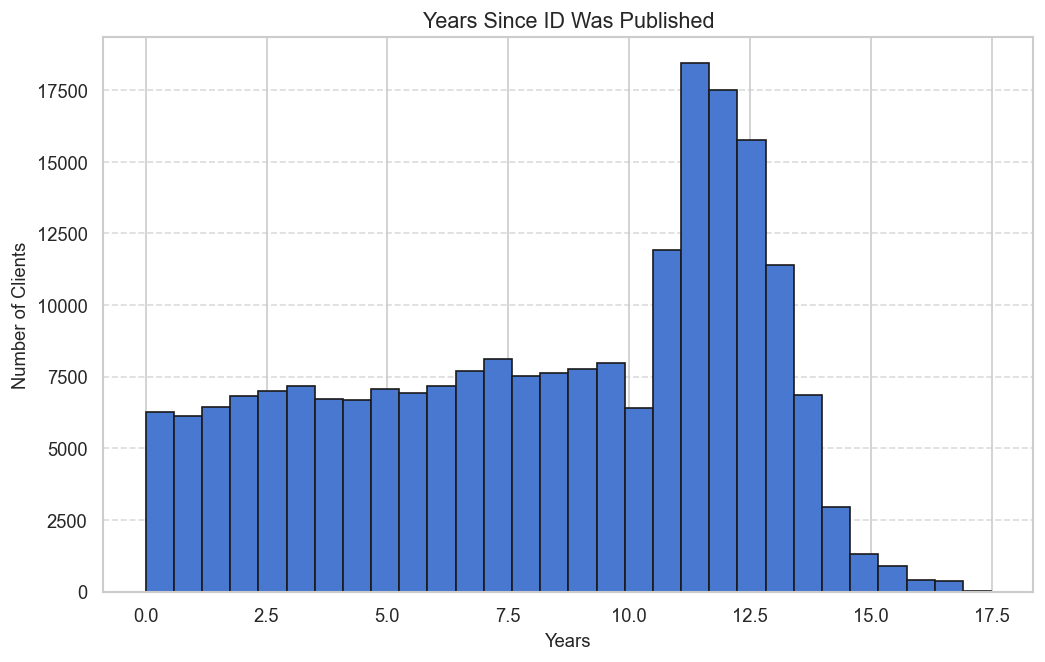

In [51]:
plt.figure(figsize=(10,6))

plt.hist(
    abs(train['days_id_publish']) / 365,
    bins=30,
    edgecolor='k'
)

plt.title('Years Since ID Was Published')

plt.xlabel('Years')

plt.ylabel('Number of Clients')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

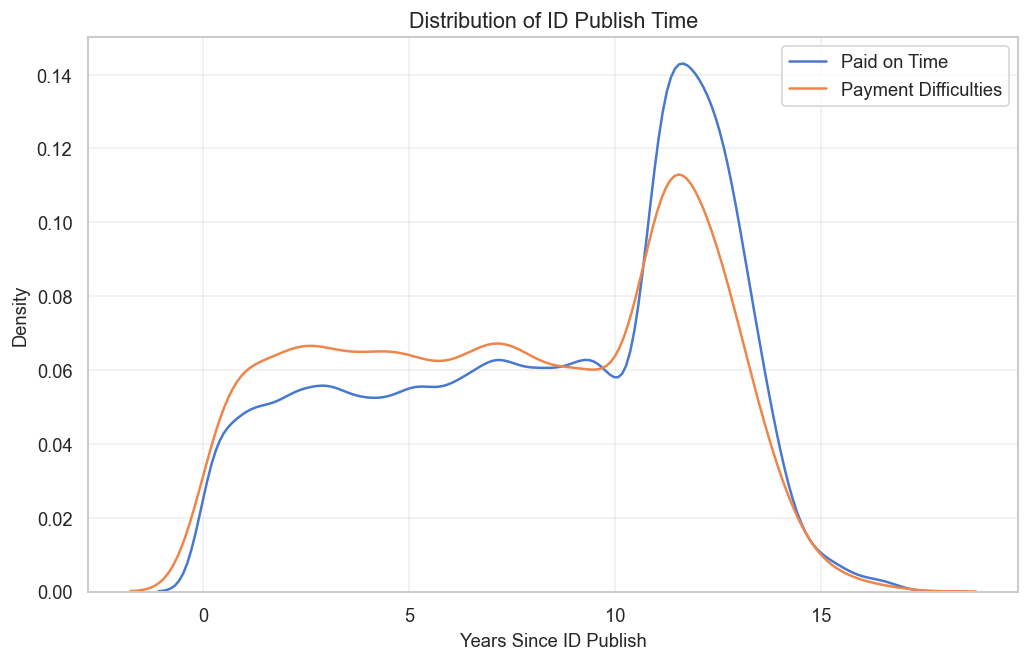

In [52]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    abs(train.loc[train['target'] == 0,
    'days_id_publish']) / 365,
    label='Paid on Time'
)

sns.kdeplot(
    abs(train.loc[train['target'] == 1,
    'days_id_publish']) / 365,
    label='Payment Difficulties'
)

plt.xlabel('Years Since ID Publish')

plt.ylabel('Density')

plt.title('Distribution of ID Publish Time')

plt.legend()

plt.grid(alpha=0.3)

plt.show()

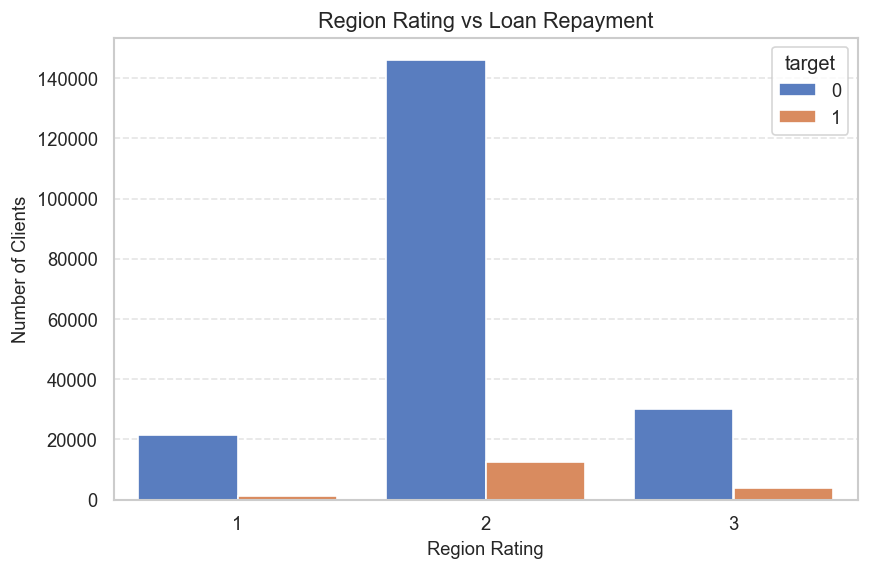

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='region_rating_client',
    hue='target',
    data=train
)

plt.title('Region Rating vs Loan Repayment')

plt.xlabel('Region Rating')

plt.ylabel('Number of Clients')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

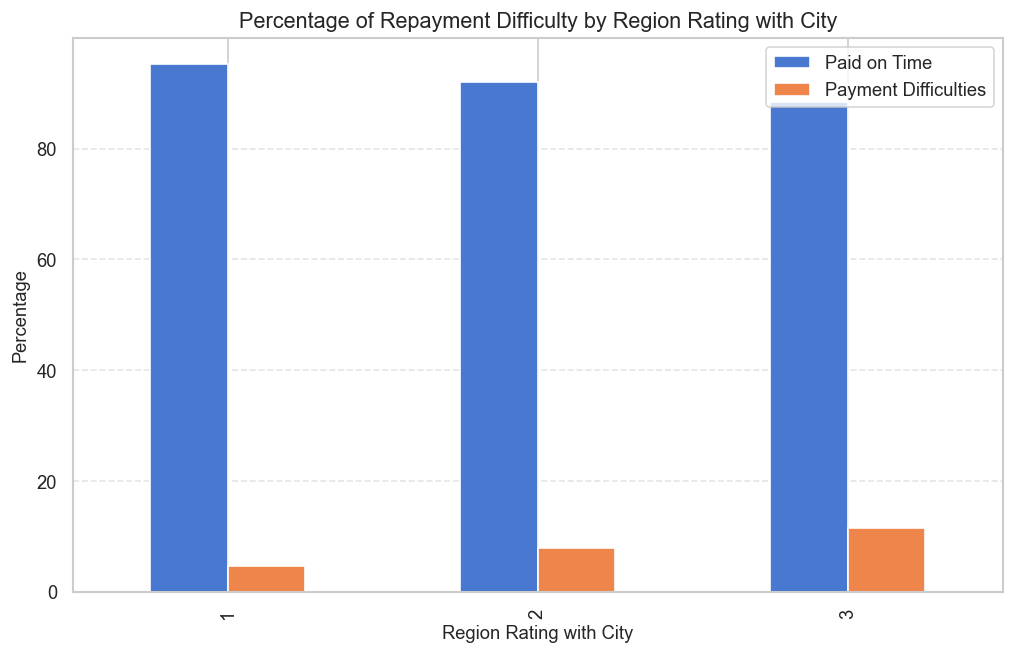

In [54]:
region_target = pd.crosstab(
    train['region_rating_client_w_city'],
    train['target'],
    normalize='index'
) * 100

region_target.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    'Percentage of Repayment Difficulty by Region Rating with City'
)

plt.xlabel('Region Rating with City')

plt.ylabel('Percentage')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend([
    'Paid on Time',
    'Payment Difficulties'
])

plt.show()

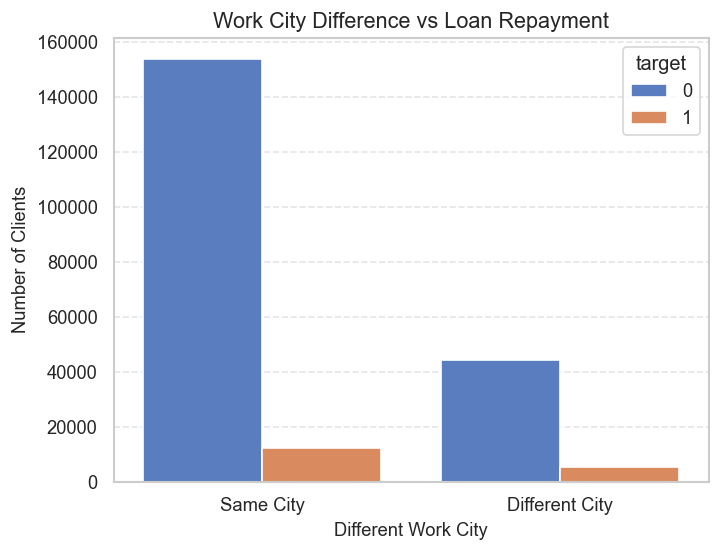

In [55]:
sns.countplot(
    x='reg_city_not_work_city',
    hue='target',
    data=train
)

plt.title(
    'Work City Difference vs Loan Repayment'
)

plt.xlabel(
    'Different Work City'
)

plt.ylabel(
    'Number of Clients'
)

plt.xticks(
    [0,1],
    ['Same City', 'Different City']
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### 4.1 Resampling

In [56]:
# SMOTE Method
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=0)

X_develop_smote, y_develop_smote = smote.fit_resample(X,y) # type: ignore

print( "Paid on time y_develop Percentage" , round(y_develop_smote.value_counts(normalize = True)[0] * 100 ,2) , "%")
print ( "Not Paid on Time y_develop Percentage" , (round(y_develop_smote.value_counts(normalize = True)[1] * 100 , 2)), "% \n")

Paid on time y_develop Percentage 50.0 %
Not Paid on Time y_develop Percentage 50.0 % 



In [57]:
# Under Sampling Method
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

X_develop_rus, y_develop_rus = rus.fit_resample(X,y) # type: ignore

print( "Paid on time y_develop Percentage" , round(y_develop_rus.value_counts(normalize = True)[0] * 100 ,2) , "%")
print ( "Not Paid on Time y_develop Percentage" , (round(y_develop_rus.value_counts(normalize = True)[1] * 100 , 2)), "% \n")


Paid on time y_develop Percentage 50.0 %
Not Paid on Time y_develop Percentage 50.0 % 



In [58]:
# Over Sampler Method
ros = RandomOverSampler(sampling_strategy='auto',random_state=42)

X_resampled, y_resampled = ros.fit_resample( X, y) # type: ignore

print( "Paid on time y_develop Percentage" , round(y_resampled.value_counts(normalize = True)[0] * 100 ,2) , "%")
print ( "Not Paid on Time y_develop Percentage" , (round(y_resampled.value_counts(normalize = True)[1] * 100 , 2)), "% \n")

Paid on time y_develop Percentage 50.0 %
Not Paid on Time y_develop Percentage 50.0 % 



In [59]:
import plotly.graph_objects as go
import plotly.io as pio
# Counts
methods = ['Original', 'Random Over', 'Random Under', 'SMOTE 0.7']

counts0 = [
    (y_develop == 0).sum(),
    (y_resampled == 0).sum(),
    (y_develop_rus == 0).sum(),
    (y_develop_smote == 0).sum()
]

counts1 = [
    (y_develop == 1).sum(),
    (y_resampled == 1).sum(),
    (y_develop_rus == 1).sum(),
    (y_develop_smote == 1).sum()
]

# Optional table for checking
df_compare = pd.DataFrame({
    'Method': methods,
    'Class 0': counts0,
    'Class 1': counts1
})
print(df_compare)

# Bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    name='Class 0',
    x=methods,
    y=counts0,
    text=counts0,
    textposition='outside'
))

fig.add_trace(go.Bar(
    name='Class 1',
    x=methods,
    y=counts1,
    text=counts1,
    textposition='outside'
))

fig.update_layout(
    title='Target Class Distribution After Resampling',
    xaxis_title='Resampling Method',
    yaxis_title='Count',
    barmode='group',
    template='plotly_white',
    legend_title='target',
    width=1000,
    height=600
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', rangemode='tozero')

pio.renderers.default = "browser"
fig.write_html("resampling_compare.html")

         Method  Class 0  Class 1
0      Original    79126     6976
1   Random Over   197809   197809
2  Random Under    17448    17448
3     SMOTE 0.7   197809   197809


In [60]:
train = pd.concat([X_develop_rus, y_develop_rus], axis = 1)
train.shape

(34896, 52)

#### 4.2 Using Models 


In [61]:
X_develop, X_test, y_develop, y_test = train_test_split(X_resampled, y_resampled, test_size=0.6, random_state=42)

print( "Paid on time y_develop Percentage" , round(y_develop.value_counts(normalize = True)[0] * 100 ,2) , "%")
print ( "Not Paid on Time y_develop Percentage" , (round(y_develop.value_counts(normalize = True)[1] * 100 , 2)), "% \n")

print( "Paid on time y_test Percentage" , round(y_test.value_counts(normalize = True)[0] * 100 ,2) , "%")
print ( "Not Paid on Time y_test Percentage" , 100 - (round(y_test.value_counts(normalize = True)[0] * 100 ,2)), "%")

Paid on time y_develop Percentage 50.04 %
Not Paid on Time y_develop Percentage 49.96 % 

Paid on time y_test Percentage 49.97 %
Not Paid on Time y_test Percentage 50.03 %


## Logistic Regression

In [62]:
log = linear_model.LogisticRegression(random_state = 42)
log.fit(X_develop,y_develop)

y_pred = log.predict(X_test)
y_prob = log.predict_proba(X_test)[:, 1]

In [63]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report)

In [64]:
print("Accuracy :", round(accuracy_score(y_test, y_pred)*100 ,2) ,"%")
print("Precision:", round(precision_score(y_test, y_pred)*100,2),"%" ) # type: ignore
print("Recall   :", round(recall_score(y_test, y_pred)*100,2) ,"%") # type: ignore
print("F1-score :", round(f1_score(y_test, y_pred)*100,2) ,"%") # type: ignore
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob)*100 ,2 ) ,"%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy : 57.31 %
Precision: 57.61 %
Recall   : 55.47 %
F1-score : 56.52 %
ROC-AUC  : 59.83 %

Confusion Matrix:
 [[70153 48465]
 [52878 65875]]

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.59      0.58    118618
           1       0.58      0.55      0.57    118753

    accuracy                           0.57    237371
   macro avg       0.57      0.57      0.57    237371
weighted avg       0.57      0.57      0.57    237371



## Random Forest

In [65]:
rf_model = RandomForestClassifier(n_estimators = 150, random_state = 50, verbose = 2, n_jobs = -1)
rf_model.fit(X_develop, y_develop)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

building tree 2 of 150
building tree 3 of 150
building tree 4 of 150
building tree 1 of 150


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.


building tree 5 of 150
building tree 6 of 150
building tree 7 of 150
building tree 8 of 150
building tree 9 of 150
building tree 10 of 150
building tree 11 of 150
building tree 12 of 150
building tree 13 of 150
building tree 14 of 150
building tree 15 of 150
building tree 16 of 150
building tree 17 of 150
building tree 18 of 150
building tree 19 of 150
building tree 20 of 150
building tree 21 of 150
building tree 22 of 150
building tree 23 of 150
building tree 24 of 150
building tree 25 of 150
building tree 26 of 150
building tree 27 of 150
building tree 28 of 150
building tree 29 of 150building tree 30 of 150

building tree 31 of 150
building tree 32 of 150
building tree 33 of 150
building tree 34 of 150
building tree 35 of 150
building tree 36 of 150
building tree 37 of 150
building tree 38 of 150


[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:   16.9s


building tree 39 of 150
building tree 40 of 150
building tree 41 of 150
building tree 42 of 150
building tree 43 of 150
building tree 44 of 150
building tree 45 of 150
building tree 46 of 150
building tree 47 of 150
building tree 48 of 150
building tree 49 of 150
building tree 50 of 150
building tree 51 of 150
building tree 52 of 150
building tree 53 of 150
building tree 54 of 150
building tree 55 of 150
building tree 56 of 150
building tree 57 of 150
building tree 58 of 150
building tree 59 of 150
building tree 60 of 150
building tree 61 of 150
building tree 62 of 150
building tree 63 of 150
building tree 64 of 150
building tree 65 of 150
building tree 66 of 150
building tree 67 of 150
building tree 68 of 150
building tree 69 of 150
building tree 70 of 150
building tree 71 of 150
building tree 72 of 150
building tree 73 of 150
building tree 74 of 150
building tree 75 of 150
building tree 76 of 150
building tree 77 of 150
building tree 78 of 150
building tree 79 of 150
building tree 80

[Parallel(n_jobs=-1)]: Done 150 out of 150 | elapsed:   58.5s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done 150 out of 150 | elapsed:    6.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done 150 out of 150 | elapsed:    6.2s finished


In [66]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf)*100 ,2) ,"%")
print("Precision:", round(precision_score(y_test, y_pred_rf)*100,2),"%" ) # type: ignore
print("Recall   :", round(recall_score(y_test, y_pred_rf)*100,2) ,"%") # type: ignore
print("F1-score :", round(f1_score(y_test, y_pred_rf)*100,2) ,"%") # type: ignore
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf)*100 ,2 ) ,"%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy : 98.19 %
Precision: 97.26 %
Recall   : 99.17 %
F1-score : 98.2 %
ROC-AUC  : 99.72 %

Confusion Matrix:
 [[115300   3318]
 [   989 117764]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98    118618
           1       0.97      0.99      0.98    118753

    accuracy                           0.98    237371
   macro avg       0.98      0.98      0.98    237371
weighted avg       0.98      0.98      0.98    237371



## XGBoost with Scale

In [67]:
from xgboost import XGBClassifier

# Handles imbalance natively — no SMOTE needed
scale = (y_develop == 0).sum() / (y_develop == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,
    eval_metric='auc',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_develop, y_develop,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_xgb) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred_xgb) * 100, 2), "%") # type: ignore
print("Recall   :", round(recall_score(y_test, y_pred_xgb) * 100, 2), "%") # type: ignore
print("F1-Score :", round(f1_score(y_test, y_pred_xgb) * 100, 2), "%") # type: ignore
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_xgb) * 100, 2), "%") # type: ignore
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

=== XGBoost ===
Accuracy : 75.9 %
Precision: 74.91 %
Recall   : 77.93 %
F1-Score : 76.39 %
ROC-AUC  : 83.87 %

Confusion Matrix:
 [[87619 30999]
 [26210 92543]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.74      0.75    118618
           1       0.75      0.78      0.76    118753

    accuracy                           0.76    237371
   macro avg       0.76      0.76      0.76    237371
weighted avg       0.76      0.76      0.76    237371



In [68]:
from lightgbm import LGBMClassifier , early_stopping


lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    class_weight='balanced',   # handles imbalance
    metrics= 'auc',
    callbacks=[early_stopping(stopping_rounds=50, verbose=False)],
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(
    X_develop, y_develop,
    eval_set=[(X_test, y_test)],
    
)

y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("=== LightGBM ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_lgbm) * 100, 2), "%")# type: ignore
print("Precision:", round(precision_score(y_test, y_pred_lgbm) * 100, 2), "%")# type: ignore
print("Recall   :", round(recall_score(y_test, y_pred_lgbm) * 100, 2), "%") # type: ignore
print("F1-Score :", round(f1_score(y_test, y_pred_lgbm) * 100, 2), "%")# type: ignore
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_lgbm) * 100, 2), "%")


=== LightGBM ===
Accuracy : 73.4 %
Precision: 72.85 %
Recall   : 74.65 %
F1-Score : 73.74 %
ROC-AUC  : 81.27 %


## Stacking Ensemble

In [69]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

scale = (y_develop == 0).sum() / (y_develop == 1).sum()

xgb_stack = XGBClassifier(
    n_estimators=150,          
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1
)

lgbm_stack = LGBMClassifier(
    n_estimators=150,         # Fixed safe number of trees
    max_depth=6,
    learning_rate=0.05,
    class_weight='balanced',   
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# 3. Put your estimators list together
estimators = [
    ('lr',   LogisticRegression(max_iter=1000, random_state=42)),
    ('rf',   rf_model), # Assuming rf_model is defined above
    ('xgb',  xgb_stack),
    ('lgbm', lgbm_stack)
]

# 4. Initialize StackingClassifier
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),  # meta-learner
    cv=5,
    n_jobs=-1
)
# 3. Put your estimators list together
estimators = [
    ('lr',   LogisticRegression(max_iter=1000, random_state=42)),
    ('rf',   rf_model), # Assuming rf_model is defined above
    ('xgb',  xgb_stack),
    ('lgbm', lgbm_stack)
]

# 4. Initialize StackingClassifier
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),  # meta-learner
    cv=5,
    n_jobs=-1
)


stack.fit(X_develop, y_develop)

y_pred_stack = stack.predict(X_test)
y_prob_stack = stack.predict_proba(X_test)[:, 1]

print("=== Stacking Classifier ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_stack) * 100, 2), "%") # type: ignore
print("Precision:", round(precision_score(y_test, y_pred_stack) * 100, 2), "%") # type: ignore
print("Recall   :", round(recall_score(y_test, y_pred_stack) * 100, 2), "%")# type: ignore
print("F1-Score :", round(f1_score(y_test, y_pred_stack) * 100, 2), "%") # type: ignore
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_stack) * 100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_stack))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stack))

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    1.7s
[Parallel(n_jobs=4)]: Done 150 out of 150 | elapsed:    6.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    1.3s
[Parallel(n_jobs=4)]: Done 150 out of 150 | elapsed:    6.1s finished


=== Stacking Classifier ===
Accuracy : 99.38 %
Precision: 99.7 %
Recall   : 99.06 %
F1-Score : 99.38 %
ROC-AUC  : 99.66 %

Confusion Matrix:
 [[118266    352]
 [  1113 117640]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99    118618
           1       1.00      0.99      0.99    118753

    accuracy                           0.99    237371
   macro avg       0.99      0.99      0.99    237371
weighted avg       0.99      0.99      0.99    237371



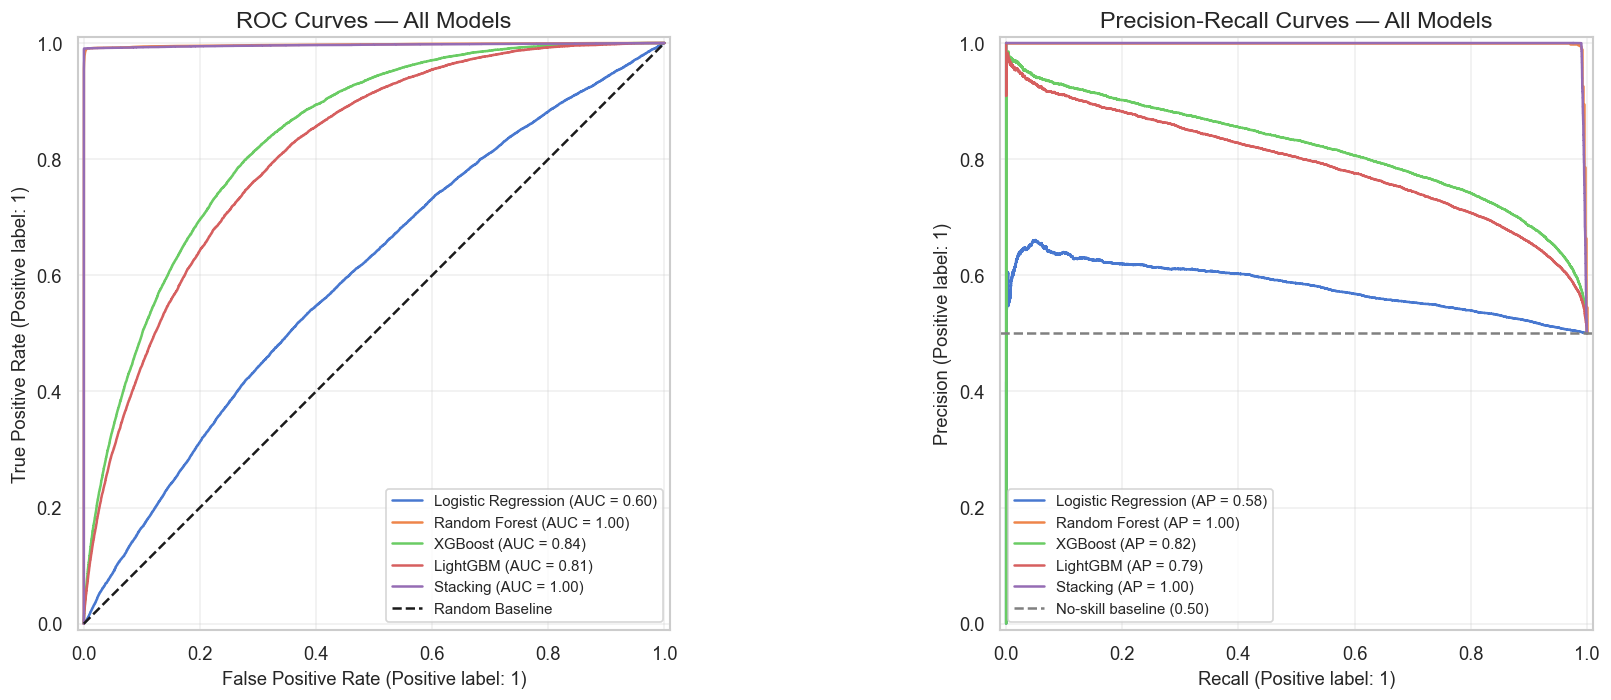

In [70]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = {
    'Logistic Regression': (log,   y_prob),
    'Random Forest':       (rf_model, y_prob_rf),
    'XGBoost':             (xgb,   y_prob_xgb),
    'LightGBM':            (lgbm,  y_prob_lgbm),
    'Stacking':            (stack, y_prob_stack)
}

for name, (model, prob) in models.items():
    RocCurveDisplay.from_predictions(y_test, prob, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_predictions(y_test, prob, ax=axes[1], name=name)

axes[0].set_title('ROC Curves — All Models', fontsize=14)
axes[0].plot([0,1],[0,1],'k--', label='Random Baseline')

axes[1].set_title('Precision-Recall Curves — All Models', fontsize=14)
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--',
                label=f'No-skill baseline ({y_test.mean():.2f})')

for ax in axes:
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150)
plt.show()

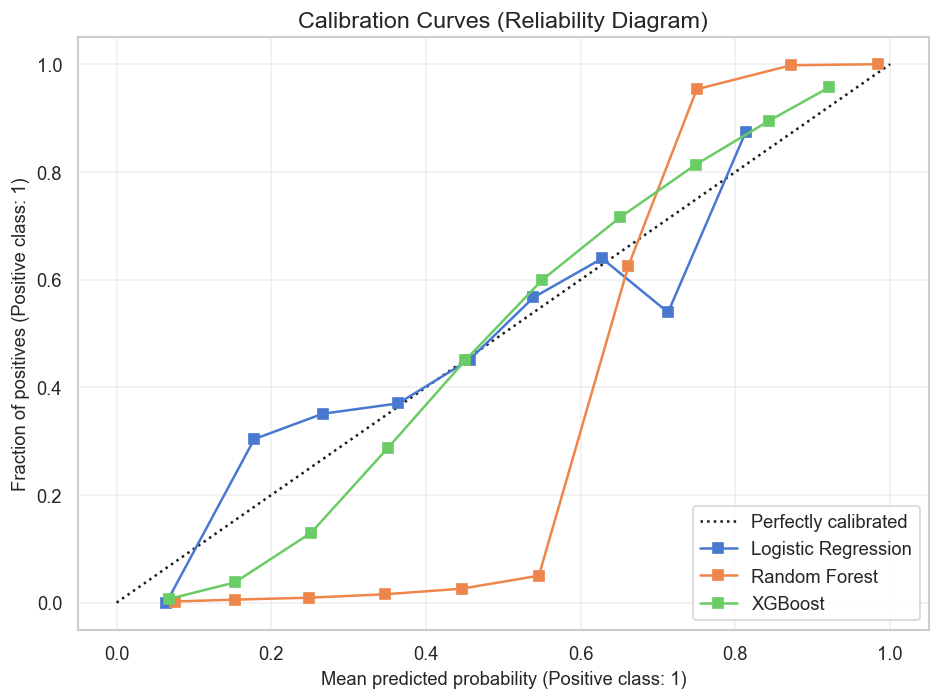

In [71]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for name, prob in [('Logistic Regression', y_prob),
                   ('Random Forest',       y_prob_rf),
                   ('XGBoost',             y_prob_xgb)]:
    CalibrationDisplay.from_predictions(y_test, prob, n_bins=10, ax=ax, name=name)

ax.set_title('Calibration Curves (Reliability Diagram)', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150)
plt.show()

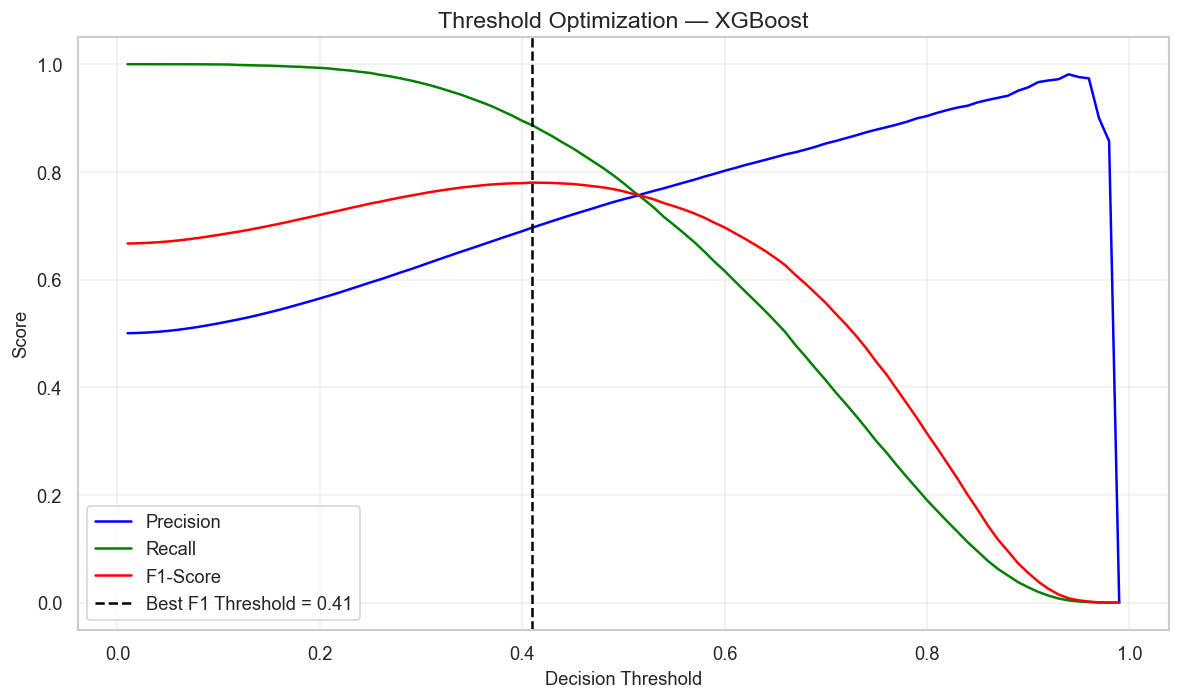

Optimal threshold: 0.41


In [72]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

thresholds = np.arange(0.01, 1.0, 0.01)

precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

best_thresh = thresholds[np.argmax(f1s)]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision', color='blue')
plt.plot(thresholds, recalls,    label='Recall',    color='green')
plt.plot(thresholds, f1s,        label='F1-Score',  color='red')
plt.axvline(x=best_thresh, color='black', linestyle='--',
            label=f'Best F1 Threshold = {best_thresh:.2f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Threshold Optimization — XGBoost', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=150)
plt.show()

print(f"Optimal threshold: {best_thresh:.2f}")

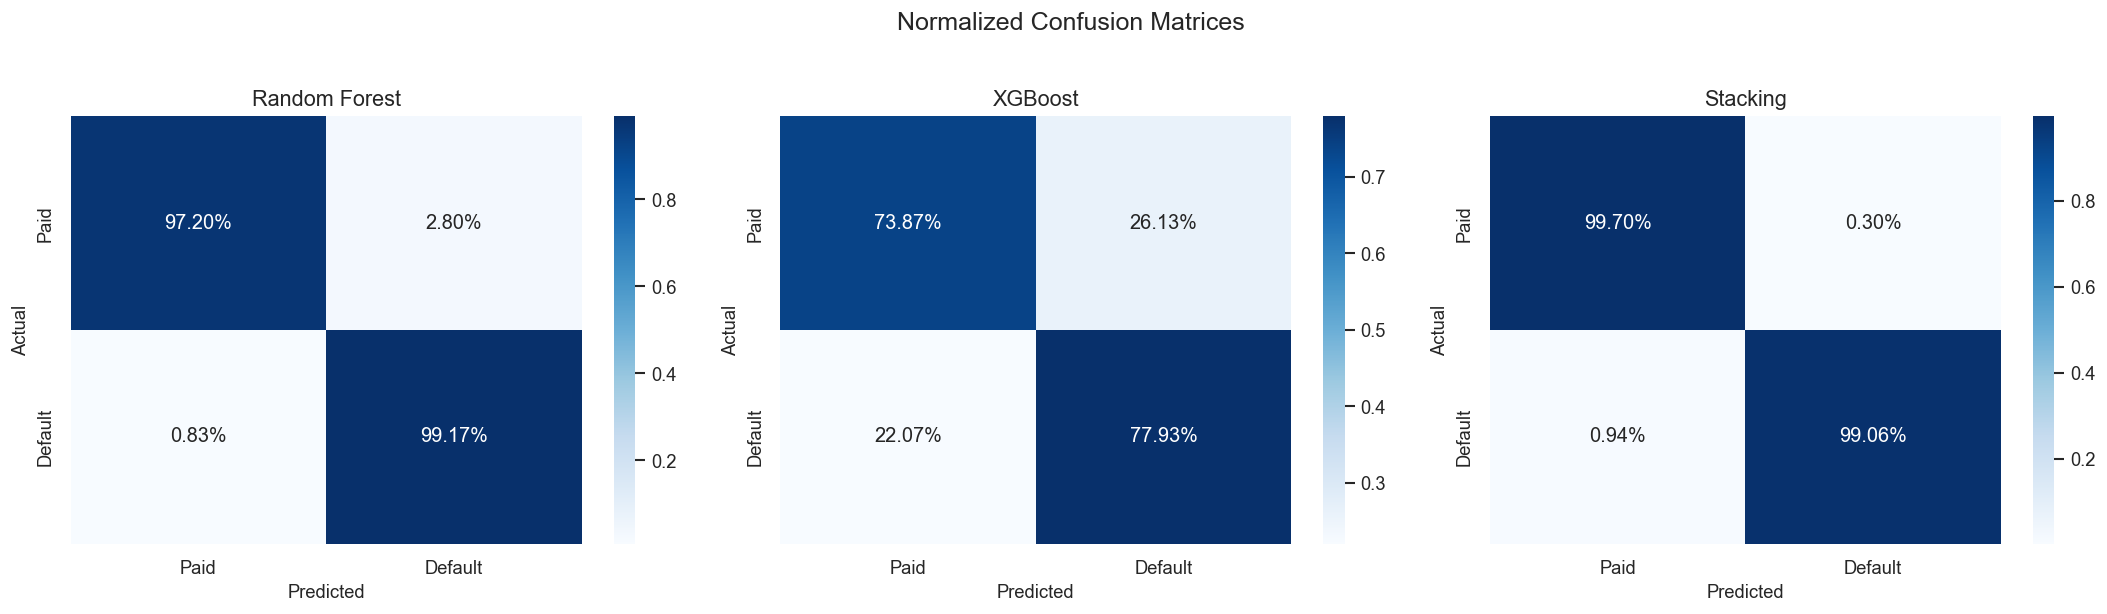

In [73]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_p) in zip(axes, [('Random Forest', y_pred_rf),
                                    ('XGBoost',       y_pred_xgb),
                                    ('Stacking',      y_pred_stack)]):
    cm = confusion_matrix(y_test, y_p, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', ax=ax,
                xticklabels=['Paid', 'Default'],
                yticklabels=['Paid', 'Default'])
    ax.set_title(f'{name}', fontsize=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Normalized Confusion Matrices', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()